# **Retail Customer Churn Prediction**

##### Project Type: Data Science project
##### Project By: Madhuri Hawaldar
##### Contribution: Individual

## Introduction

This project focuses on performing an in-depth exploratory data analysis (EDA) on a retail dataset, comprising client and pricing information. The primary goal is to understand customer behavior, identify key characteristics, and ultimately gain insights into factors influencing customer churn. By analyzing various numerical and categorical features, we aim to uncover patterns and relationships within the data.



## Objective


The main objective of this project is to:

- Understand Customer Behavior: Analyze client demographics, consumption patterns, contract details, and pricing structures.
- Identify Churn Drivers: Explore the relationship between various features (e.g., consumption, pricing, sales channels, contract terms) and customer churn.
- Data Preparation for Modeling: Clean, preprocess, and engineer features from the raw data to prepare it for subsequent machine learning model development.
- The insights gained from this EDA will be crucial for building a robust churn prediction model, which can help the retail company proactively identify at-risk customers and implement targeted retention strategies.

## 1. Import packages

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

# Shows plots in jupyter notebook
%matplotlib inline

# Set plot style
sns.set(color_codes=True)

---

## Loading data with Pandas

We need to load client_data.csv and price_data.csv into individual dataframes so that we can work with them in Python. For this notebook and all further notebooks, it will be assumed that the CSV files will the placed in the same file location as the notebook. If they are not, please adjust the directory within the read_csv method accordingly.

In [ ]:
client_df = pd.read_csv('/content/drive/MyDrive/client_data (1).csv')
price_df = pd.read_csv('/content/drive/MyDrive/price_data (1).csv')

In [ ]:
# view first 5 rows of client_df
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [ ]:
# view first 5 rows of price_df
price_df.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [ ]:
# Number of rows and columns in client_df
client_df.shape

(14606, 26)

In [ ]:
# Number of rows and columns in price_df
price_df.shape

(193002, 8)

In [ ]:
# column names from client_df
client_df.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max', 'churn'],
      dtype='object')

In [ ]:
# column names from price_df
price_df.columns

Index(['id', 'price_date', 'price_off_peak_var', 'price_peak_var',
       'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix',
       'price_mid_peak_fix'],
      dtype='object')

## Descriptive statistics of data

In [92]:
# column data types in client_df
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 61 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              14606 non-null  object 
 1   cons_12m                                        14606 non-null  float64
 2   cons_gas_12m                                    14606 non-null  float64
 3   cons_last_month                                 14606 non-null  float64
 4   forecast_cons_12m                               14606 non-null  float64
 5   forecast_discount_energy                        14606 non-null  float64
 6   forecast_meter_rent_12m                         14606 non-null  float64
 7   forecast_price_energy_off_peak                  14606 non-null  float64
 8   forecast_price_energy_peak                      14606 non-null  float64
 9   forecast_price_pow_off_peak            

In [ ]:
# column data types in price_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  object 
 1   price_date          193002 non-null  object 
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), object(2)
memory usage: 11.8+ MB


In [ ]:
client_df.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


In [ ]:
price_df.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


## Data Description

#### **Data Description : client_df**

- The client_df DataFrame contains 14606 entries and 26 columns.
- **Data Types Overview:**
  - Object (8 columns): `id`, `channel_sales`, `date_activ`, `date_end`, `date_modif_prod`, `date_renewal`, `has_gas`, `origin_up`
  - Float64 (11 columns): `forecast_cons_12m`, `forecast_discount_energy`, `forecast_meter_rent_12m`, `forecast_price_energy_off_peak`, `forecast_price_energy_peak`, `forecast_price_pow_off_peak`, `imp_cons`, `margin_gross_pow_ele`, `margin_net_pow_ele`, `pow_max`
  - Int64 (7 columns): `cons_12m`, `cons_gas_12m`, `cons_last_month`, `forecast_cons_year`, `nb_prod_act`, `net_margin`, `num_years_antig`, `churn`

- All columns appear to have no missing values, as indicated by the 14606 non-null count for all columns.




**Descriptive Statistics for Numerical Columns (client_df):**
  - `cons_12m` (Consumption 12 months): Ranges from 0 to 6.2 million, with a mean of ~159k, indicating a wide range of consumption values.
  - `cons_gas_12m` (Gas consumption 12 months): Similar to electricity consumption, with a max of ~4.15 million and a mean of ~28k.
  - `cons_last_month` (Consumption last month): Ranges from 0 to 771k.
  - `forecast_cons_12m` (Forecasted consumption 12 months): Ranges from 0 to ~82.9k.
  - `forecast_cons_year` (Forecasted consumption year): Ranges from 0 to ~175k.
  - `forecast_discount_energy` (Forecasted discount on energy): Mostly 0, with a max of 30, suggesting most clients don't have discounts.
  - `forecast_meter_rent_12m` (Forecasted meter rent 12 months): Ranges from 0 to ~599.
  - `forecast_price_energy_off_peak`, `forecast_price_energy_peak`, `forecast_price_pow_off_peak`: These are price-related forecasts, with varying means and standard deviations.
  - `imp_cons` (Current paid consumption): Ranges from 0 to ~15k.
  - `margin_gross_pow_ele` (Gross margin on power subscription): Ranges from 0 to ~374.
  - `margin_net_pow_ele` (Net margin on power subscription): Similar to gross margin.
  - `nb_prod_act` (Number of active products): Mostly 1, with a max of 32, indicating most clients have one product.
  - `net_margin` (Total net margin): Ranges from 0 to ~24.5k.
  - `num_years_antig` (Number of years of seniority): Ranges from 1 to 13 years, with a mean of ~5 years.
  - `pow_max` (Subscribed power): Ranges from 3.3 to 320.
  - `churn`: A binary variable (0 or 1), with a mean of 0.097, indicating about 9.7% churn rate.


#### **Data Description : price_df**


 - The price_df DataFrame contains 193002 entries and 8 columns.

- **Data Types Overview:**
  - Object (2 columns):  `id`, `price_date`
  - Float64 (6 columns): `price_off_peak_var`, `price_peak_var`, `price_mid_peak_var`, `price_off_peak_fix`, `price_peak_fix`, `price_mid_peak_fix`

- All columns appear to have no missing values, as indicated by the `193002 non-null` count for all columns.

- `price_date`: This column is currently an `object` type and represents the date for which the prices are recorded. It should be converted to a `datetime` object for proper time-series analysis.





**Descriptive Statistics for Numerical Columns (price_df):**
  - **`price_off_peak_var`, `price_peak_var`, `price_mid_peak_var`:** These represent the variable prices (off-peak, peak, mid-peak). They show a range of values, with `price_off_peak_var` having the highest mean and `price_mid_peak_var` being mostly zeros or very small values.
  - **`price_off_peak_fix`, `price_peak_fix`, `price_mid_peak_fix`:** These represent the fixed prices (off-peak, peak, mid-peak). Similar to variable prices, `price_off_peak_fix` has the highest mean, and `price_peak_fix` and `price_mid_peak_fix` have many zero values.

### Detailed Description of Categorical Columns:

**`channel_sales`:** This column describes how the client was acquired. Let's look at its unique values and their counts.

In [ ]:
display(client_df['channel_sales'].value_counts())

,count
channel_sales,
foosdfpfkusacimwkcsosbicdxkicaua,6754
MISSING,3725
lmkebamcaaclubfxadlmueccxoimlema,1843
usilxuppasemubllopkaafesmlibmsdf,1375
ewpakwlliwisiwduibdlfmalxowmwpci,893
sddiedcslfslkckwlfkdpoeeailfpeds,11
epumfxlbckeskwekxbiuasklxalciiuu,3
fixdbufsefwooaasfcxdxadsiekoceaa,2


**`has_gas` (True if client is also a gas client, False if not):** This indicates if the client also has a gas contract. Let's see the distribution.

In [ ]:
display(client_df['has_gas'].value_counts())

,count
has_gas,
f,11955
t,2651


**`origin_up` :** This column refers to the client's power generation origin. Let's check its values.

In [ ]:
display(client_df['origin_up'].value_counts())

,count
origin_up,
lxidpiddsbxsbosboudacockeimpuepw,7097
kamkkxfxxuwbdslkwifmmcsiusiuosws,4294
ldkssxwpmemidmecebumciepifcamkci,3148
MISSING,64
usapbepcfoloekilkwsdiboslwaxobdp,2
ewxeelcelemmiwuafmddpobolfuxioce,1


## Handle 'MISSING' values in client_df
Identify and replace 'MISSING' string values with actual NaN values in categorical columns like `channel_sales` and `origin_up` within `client_df`. After replacement, check the percentage of missing values in these columns to inform further handling strategies.


**Reasoning**:
I will replace the 'MISSING' string values with `np.nan` in the specified categorical columns (`channel_sales` and `origin_up`) in `client_df`. After the replacement, I will calculate and display the percentage of missing values for these columns to assess the extent of missing data.



In [ ]:
columns_to_check = ['channel_sales', 'origin_up']

for col in columns_to_check:
    client_df[col] = client_df[col].replace('MISSING', np.nan)

print("Percentage of 'MISSING' values replaced with NaN in client_df:")
for col in columns_to_check:
    missing_percentage = client_df[col].isnull().sum() / len(client_df) * 100
    print(f"{col}: {missing_percentage:.2f}%")

Percentage of 'MISSING' values replaced with NaN in client_df:
channel_sales: 25.50%
origin_up: 0.44%


## Check and Handle Duplicates

### Subtask:
Check for and remove any duplicate rows in both `client_df` and `price_df` to ensure data integrity and avoid skewed analysis results.


**Reasoning**:
I will check for duplicate rows in `client_df` and `price_df` and remove them to ensure data integrity. Then, I will display the new shapes of the dataframes to confirm the changes.



In [ ]:
print(f"Number of duplicate rows in client_df: {client_df.duplicated().sum()}")
client_df.drop_duplicates(inplace=True)

print(f"Number of duplicate rows in price_df: {price_df.duplicated().sum()}")
price_df.drop_duplicates(inplace=True)

print(f"New shape of client_df: {client_df.shape}")
print(f"New shape of price_df: {price_df.shape}")

Number of duplicate rows in client_df: 0
Number of duplicate rows in price_df: 0
New shape of client_df: (14606, 26)
New shape of price_df: (193002, 8)


# **Visualizations**

## Visualize Churn Distribution

### Subtask:
Create a visualization (e.g., a countplot or bar chart) to show the distribution of the `churn` column in `client_df`. This will help understand the class balance of the target variable. Include appropriate labels and a title for the plot.


**Reasoning**:
I will create a countplot to visualize the distribution of the 'churn' column in `client_df` to understand the class balance, as specified in the subtask instructions. I will use `seaborn.countplot()` with appropriate labels and a title, then display the plot using `plt.show()`.



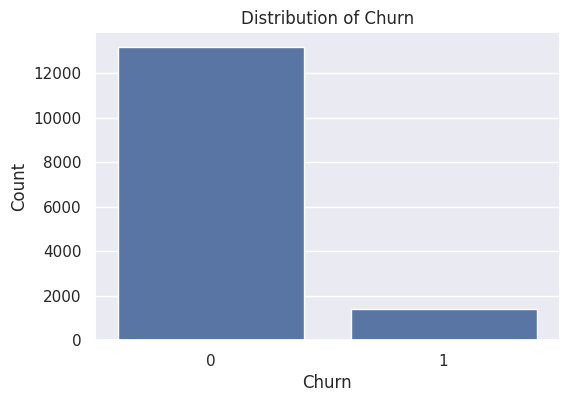

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=client_df)
plt.title('Distribution of Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

**Observation:**
The countplot reveals a significant class imbalance in the `churn` variable. The number of non-churned clients (0) is substantially higher than the number of churned clients (1). This imbalance indicates that only a small percentage of customers churn, which is typical in many customer retention datasets.

### Data Analysis Key Findings

*   **Date Column Conversion**: Several date-related columns in `client_df` (`date_activ`, `date_end`, `date_modif_prod`, `date_renewal`) and `price_df` (`price_date`) were successfully converted from `object` to `datetime` format, enabling time-based analysis.
*   **Missing Value Handling**: In `client_df`, 'MISSING' string values in `channel_sales` and `origin_up` were standardized to `np.nan`. Post-standardization, `channel_sales` showed a significant 25.50% missing values, while `origin_up` had a minor 0.44% missing values.
*   **Duplicate Data**: No duplicate rows were identified in either `client_df` or `price_df`, ensuring data integrity.
*   **Churn Distribution Imbalance**: The churn distribution revealed a substantial class imbalance, with approximately 9.7% of clients identified as churners (churn = 1) and the majority as non-churners (churn = 0).



### Distribution of Numerical Features

Let's visualize the distributions of some important numerical features in `client_df` using histograms to understand their spread, central tendency, and identify any skewness or outliers.

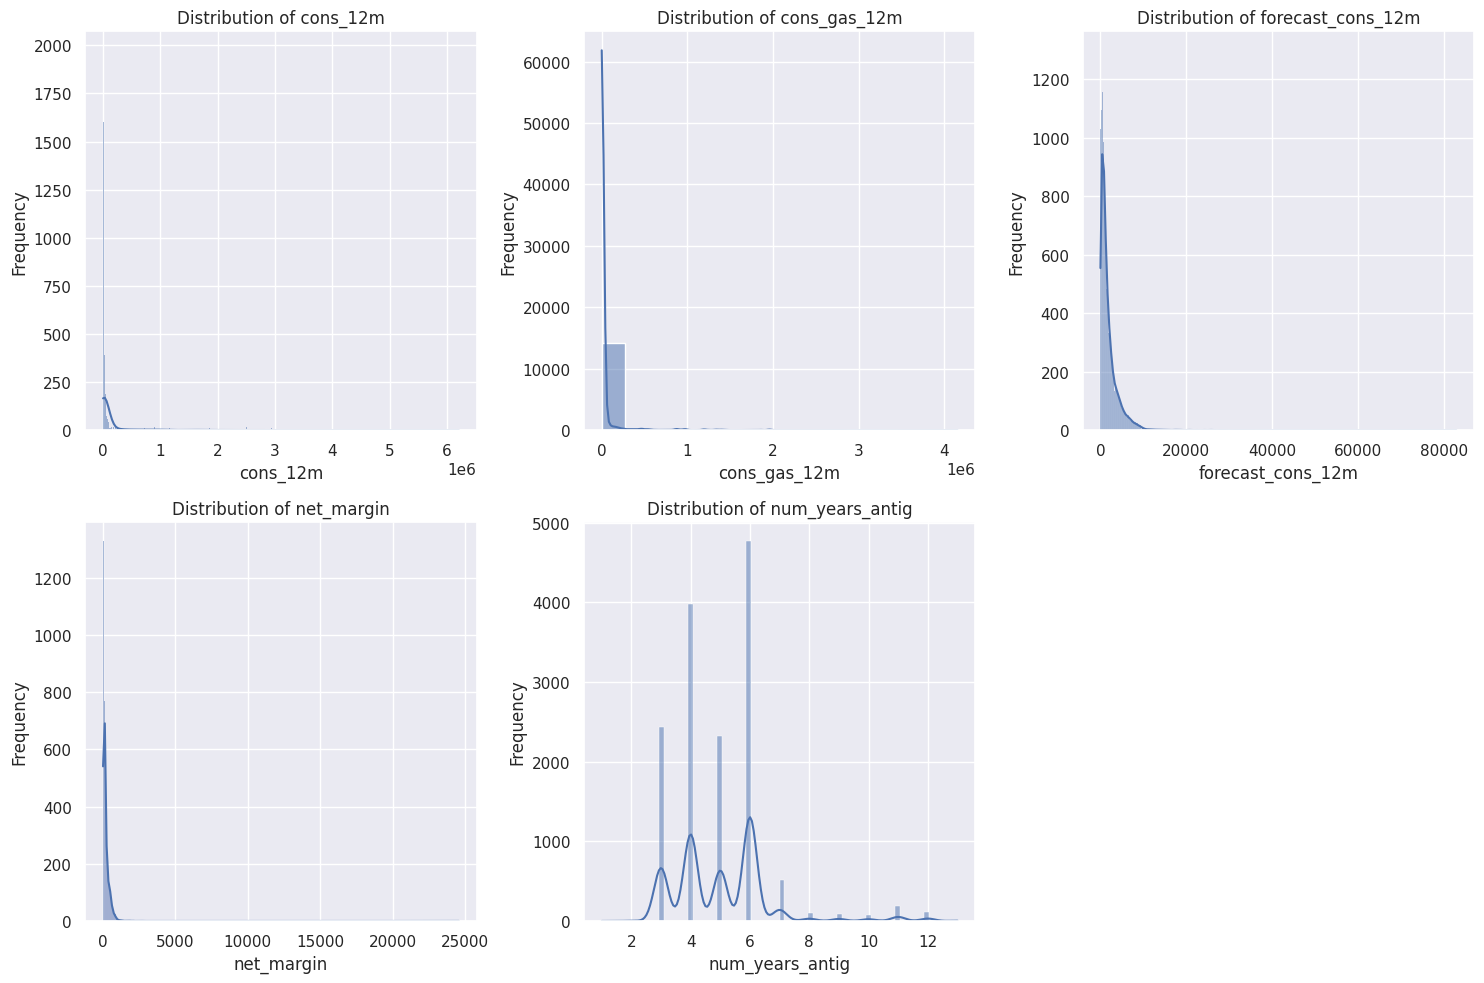

In [ ]:
numerical_features = ['cons_12m', 'cons_gas_12m', 'forecast_cons_12m', 'net_margin', 'num_years_antig']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1) # Arrange in 2 rows, 3 columns
    sns.histplot(client_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

**Observation:**
- `cons_12m` and `cons_gas_12m` show extremely skewed distributions, with most clients having very low consumption and a long tail extending to very high values. This suggests the presence of outliers and a need for potential data transformation (e.g., log transformation) for modeling purposes.
- `forecast_cons_12m`, `net_margin`, and `num_years_antig` also exhibit right-skewed distributions, although less extreme than the consumption features. Many clients have lower forecast consumption, net margins, and have been clients for fewer years.

### Distribution of Price Components in `price_df`

Let's visualize the distributions of the variable price components (`price_off_peak_var`, `price_peak_var`, `price_mid_peak_var`) using histograms. This will help us understand their typical values, ranges, and any potential skewness.

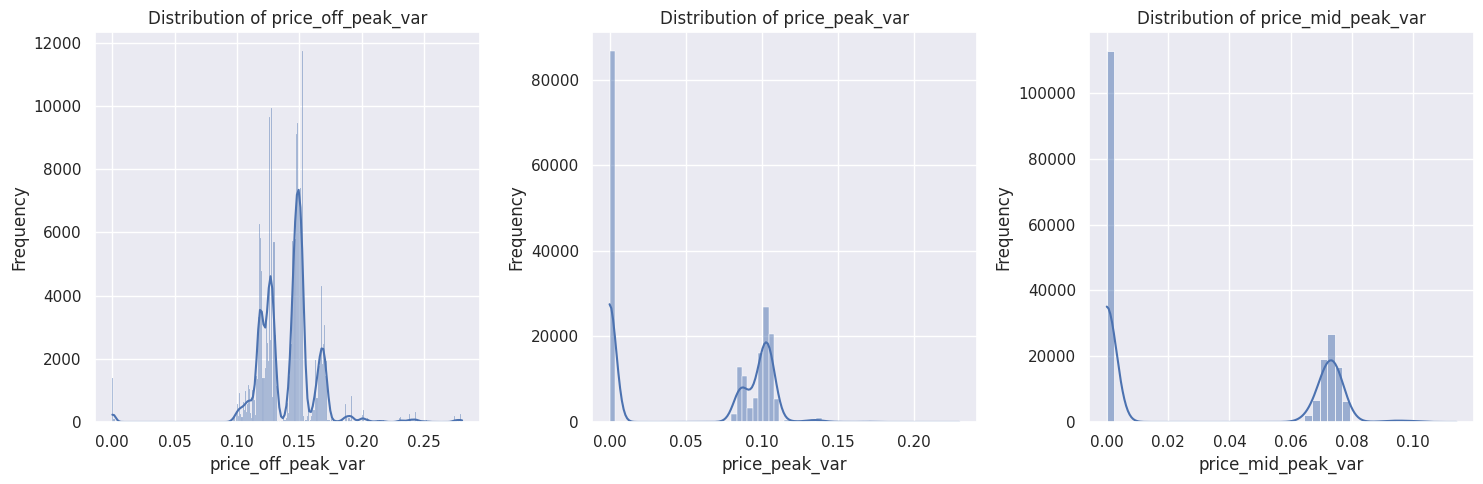

In [ ]:
price_features_var = ['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var']

plt.figure(figsize=(15, 5))
for i, col in enumerate(price_features_var):
    plt.subplot(1, 3, i + 1) # Arrange in 1 row, 3 columns
    sns.histplot(price_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Observation:

price_off_peak_var shows a relatively concentrated distribution, with most values clustering around a specific range, indicating a common off-peak variable price.
price_peak_var and price_mid_peak_var distributions are highly skewed towards zero, with a large number of values at or near zero. This suggests that peak and mid-peak variable pricing might not be universally applied or are zero for many customers.

Next, let's look at the fixed price components (`price_off_peak_fix`, `price_peak_fix`, `price_mid_peak_fix`).

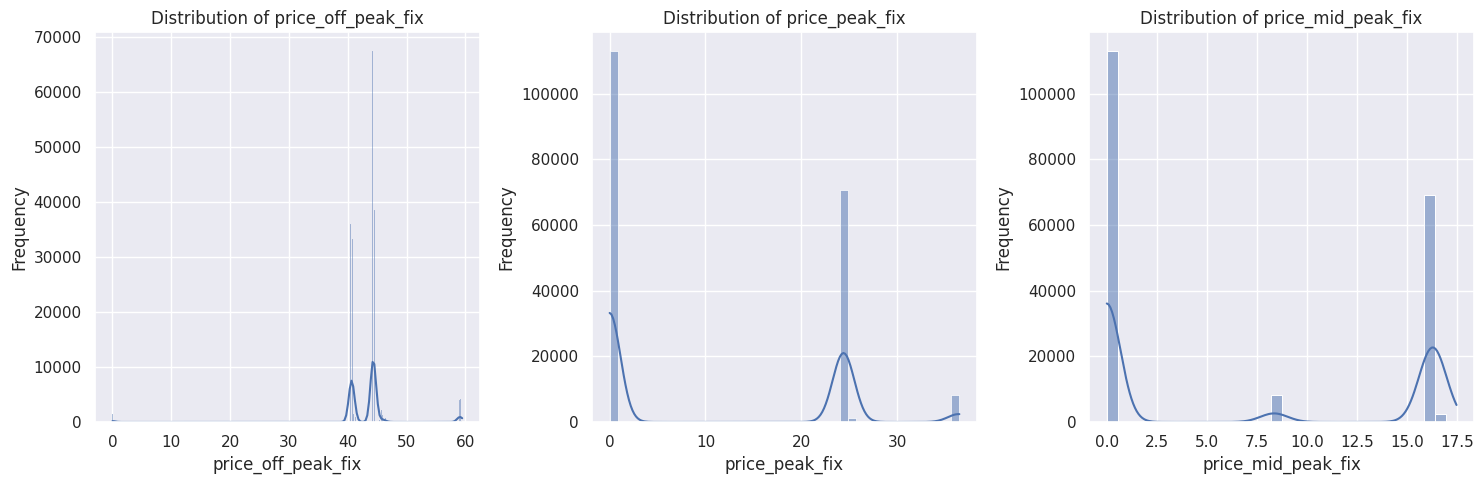

In [ ]:
price_features_fix = ['price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

plt.figure(figsize=(15, 5))
for i, col in enumerate(price_features_fix):
    plt.subplot(1, 3, i + 1) # Arrange in 1 row, 3 columns
    sns.histplot(price_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

Observation:

Similar to variable prices, price_off_peak_fix shows a more concentrated distribution, indicating a standard fixed off-peak price.
price_peak_fix and price_mid_peak_fix distributions are heavily concentrated at zero, implying that fixed charges for peak and mid-peak periods are not common or are zero for a significant portion of the customer base.

## Visualize `cons_12m` Distribution

Create a histogram to visualize the distribution of the `cons_12m` column in `client_df`. If the data appears skewed, apply a logarithmic scale to the y-axis to better represent the distribution. Include appropriate labels and a title for the plot.

**Reasoning**:
This requires visualizing the distribution of the `cons_12m` column. Given its large range and potential skewness, I will create a histogram and apply a logarithmic scale to the x-axis to better represent the distribution. I will add appropriate labels and a title to the plot.



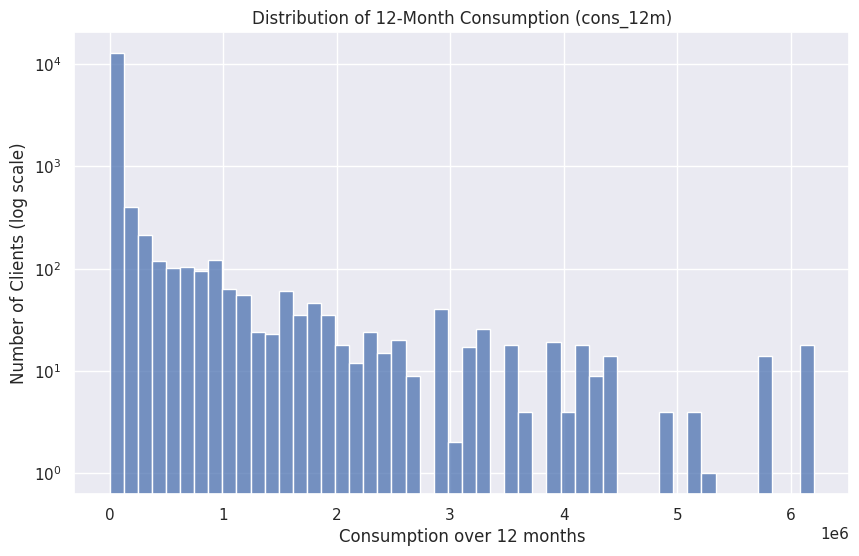

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(client_df['cons_12m'], bins=50, kde=False)
plt.yscale('log')
plt.title('Distribution of 12-Month Consumption (cons_12m)')
plt.xlabel('Consumption over 12 months')
plt.ylabel('Number of Clients (log scale)')
plt.show()

Observation: Applying a logarithmic scale to the y-axis for cons_12m reveals the true distribution more clearly. While still heavily skewed, the log scale allows us to see the spread of consumption values more effectively, highlighting that a large number of clients have very low consumption, with fewer clients consuming very high amounts. The distribution is highly concentrated at the lower end.

## Visualize Channel Sales Distribution

Missing values (NaN) will be included to understand their prevalence.


**Reasoning**:
The subtask requires visualizing the distribution of the `channel_sales` column, including NaN values, to understand client acquisition methods. I will use `seaborn.countplot` with appropriate labels and a title to generate this plot.



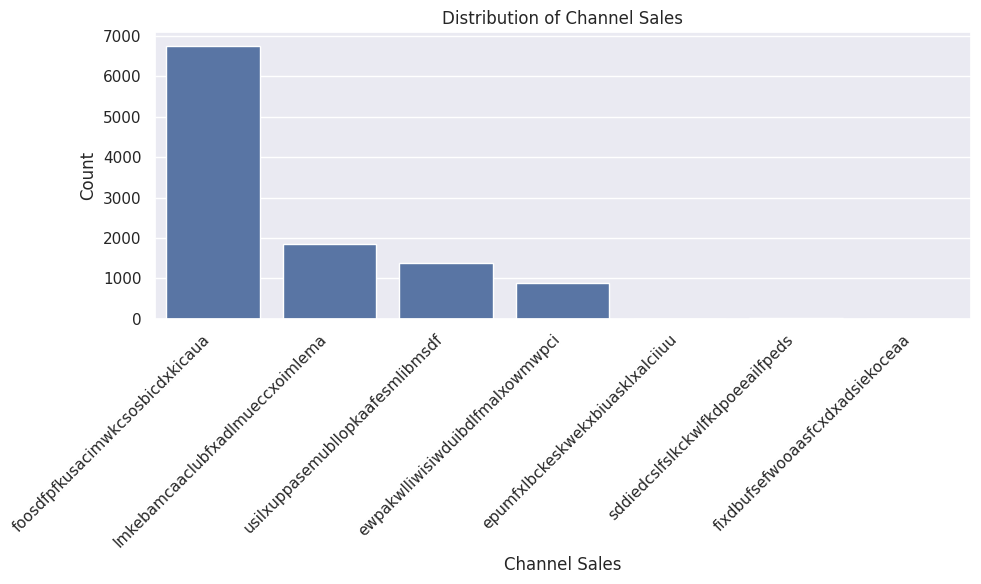

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='channel_sales', data=client_df)
plt.title('Distribution of Channel Sales')
plt.xlabel('Channel Sales')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Observation: The channel_sales distribution shows that 'foosdfpfkusacimwkcsosbicdxkicaua' is the most dominant sales channel, followed by 'MISSING' (NaN values). The presence of a significant number of NaN values (25.50% as noted earlier) for channel_sales indicates a considerable portion of clients for whom this information is unavailable. 'lmkebamcaaclubfxadlmueccxoimlema' and 'usapgsfjlfdojqfgihlascsddkde' are also notable channels but with fewer clients.

## Visualize `has_gas` Distribution by Churn Status

Create a countplot to visualize the distribution of the `has_gas` column, segmented by the `churn` status, in `client_df`. This will help determine if having a gas contract is related to customer churn.

**Reasoning**:
To understand the relationship between having a gas contract (`has_gas`) and customer churn, I will create a countplot using `seaborn.countplot`. The `churn` column will be used as the `hue` to differentiate between churned and non-churned clients for each `has_gas` category. I will include a title and axis labels for clarity.

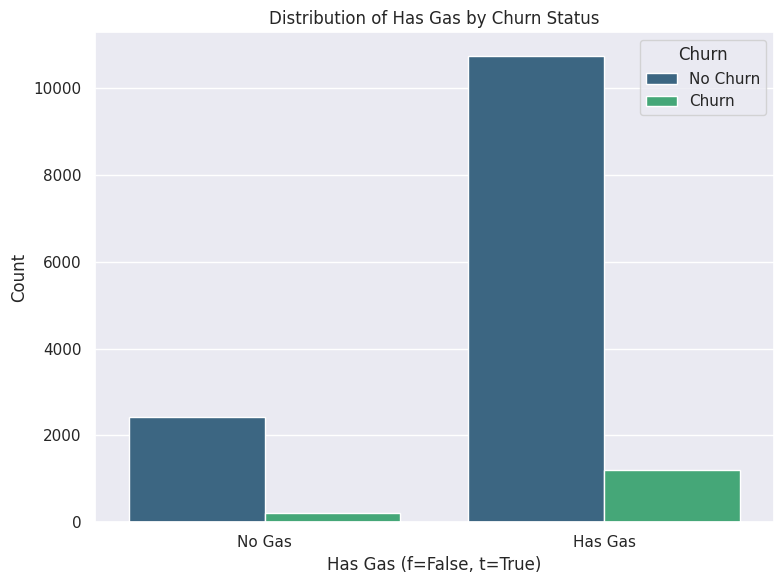

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='has_gas', hue='churn', data=client_df, palette='viridis')
plt.title('Distribution of Has Gas by Churn Status')
plt.xlabel('Has Gas (f=False, t=True)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Gas', 'Has Gas'])
plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

Observation: The countplot shows that clients without a gas contract ('No Gas') are more numerous than those with a gas contract ('Has Gas'). More importantly, among both groups, the number of non-churned clients significantly outweighs the churned clients, consistent with the overall churn imbalance. However, a deeper analysis or statistical test would be needed to determine if the proportion of churn differs significantly between clients with and without gas.

In [ ]:
def plot_stacked_bars(dataframe, title_, size_=(18, 10), rot_=0, legend_="upper right"):
    """
    Plot stacked bars with annotations
    """
    ax = dataframe.plot(
        kind="bar",
        stacked=True,
        figsize=size_,
        rot=rot_,
        title=title_
    )

    # Annotate bars
    annotate_stacked_bars(ax, textsize=14)
    # Rename legend
    plt.legend(["Retention", "Churn"], loc=legend_)
    # Labels
    plt.ylabel("Company base (%)")
    plt.show()

def annotate_stacked_bars(ax, pad=0.99, colour="white", textsize=13):
    """
    Add value annotations to the bars
    """

    # Iterate over the plotted rectanges/bars
    for p in ax.patches:

        # Calculate annotation
        value = str(round(p.get_height(),1))
        # If value is 0 do not annotate
        if value == '0.0':
            continue
        ax.annotate(
            value,
            ((p.get_x()+ p.get_width()/2)*pad-0.05, (p.get_y()+p.get_height()/2)*pad),
            color=colour,
            size=textsize
        )

def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distirbution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

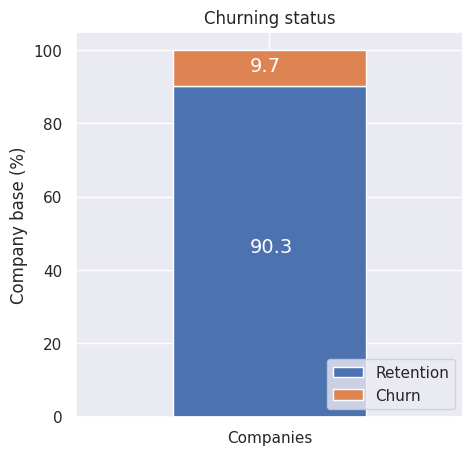

In [ ]:
churn = client_df[['id', 'churn']]
churn.columns = ['Companies', 'churn']
churn_total = churn.groupby(churn['churn']).count()
churn_percentage = churn_total / churn_total.sum() * 100
plot_stacked_bars(churn_percentage.transpose(), "Churning status", (5, 5), legend_="lower right")

Observation: The stacked bar chart clearly quantifies the overall churn status, showing that approximately 90.3% of clients are retained ('Retention'), while about 9.7% have churned ('Churn'). This visualization unequivocally highlights the class imbalance, emphasizing the need for appropriate techniques (e.g., oversampling, undersampling, or weighted models) during model development.

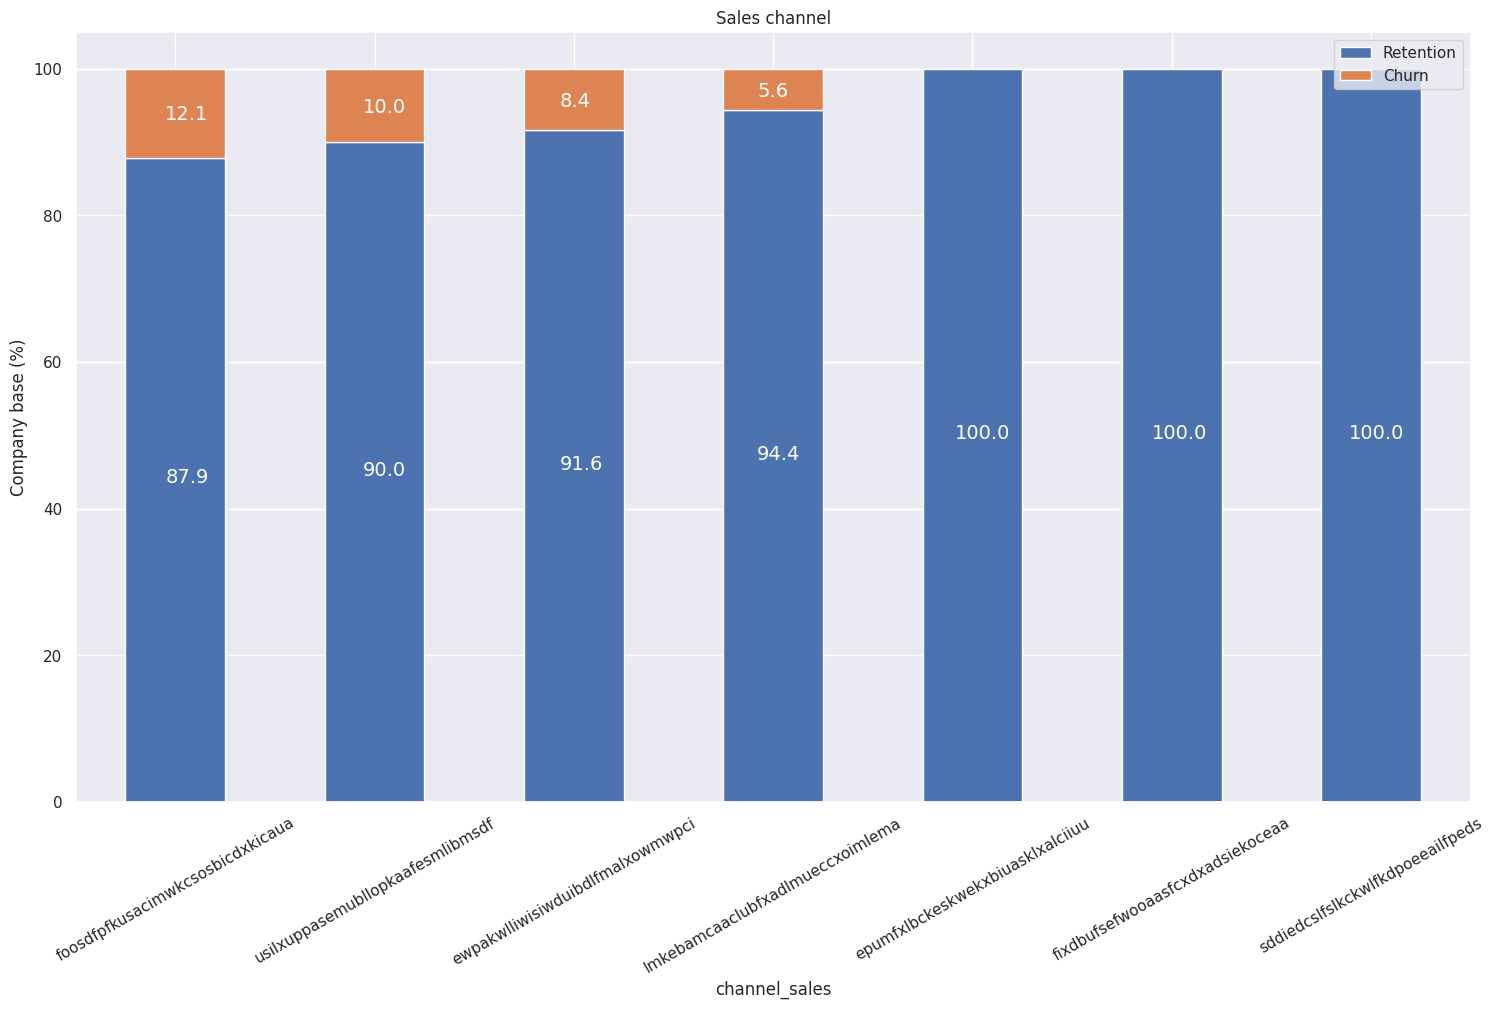

In [ ]:
channel = client_df[['id', 'channel_sales', 'churn']]
channel = channel.groupby([channel['channel_sales'], channel['churn']])['id'].count().unstack(level=1).fillna(0)
channel_churn = (channel.div(channel.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)
plot_stacked_bars(channel_churn, 'Sales channel', rot_=30)

Interestingly, the churning customers are distributed over 5 different values for `channel_sales`. As well as this, the value of `MISSING` has a churn rate of 7.6%. `MISSING` indicates a missing value and was added by the team when they were cleaning the dataset. This feature could be an important feature when it comes to building our model.

### Consumption

Let's see the distribution of the consumption in the last year and month. Since the consumption data is univariate, let's use histograms to visualize their distribution.

In [ ]:
consumption = client_df[['id', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'imp_cons', 'has_gas', 'churn']]

In [ ]:
def plot_distribution(dataframe, column, ax, bins_=50):
    """
    Plot variable distribution in a stacked histogram of churned or retained company
    """
    # Create a temporal dataframe with the data to be plot
    temp = pd.DataFrame({"Retention": dataframe[dataframe["churn"]==0][column],
    "Churn":dataframe[dataframe["churn"]==1][column]})
    # Plot the histogram
    temp[["Retention","Churn"]].plot(kind='hist', bins=bins_, ax=ax, stacked=True)
    # X-axis label
    ax.set_xlabel(column)
    # Change the x-axis to plain style
    ax.ticklabel_format(style='plain', axis='x')

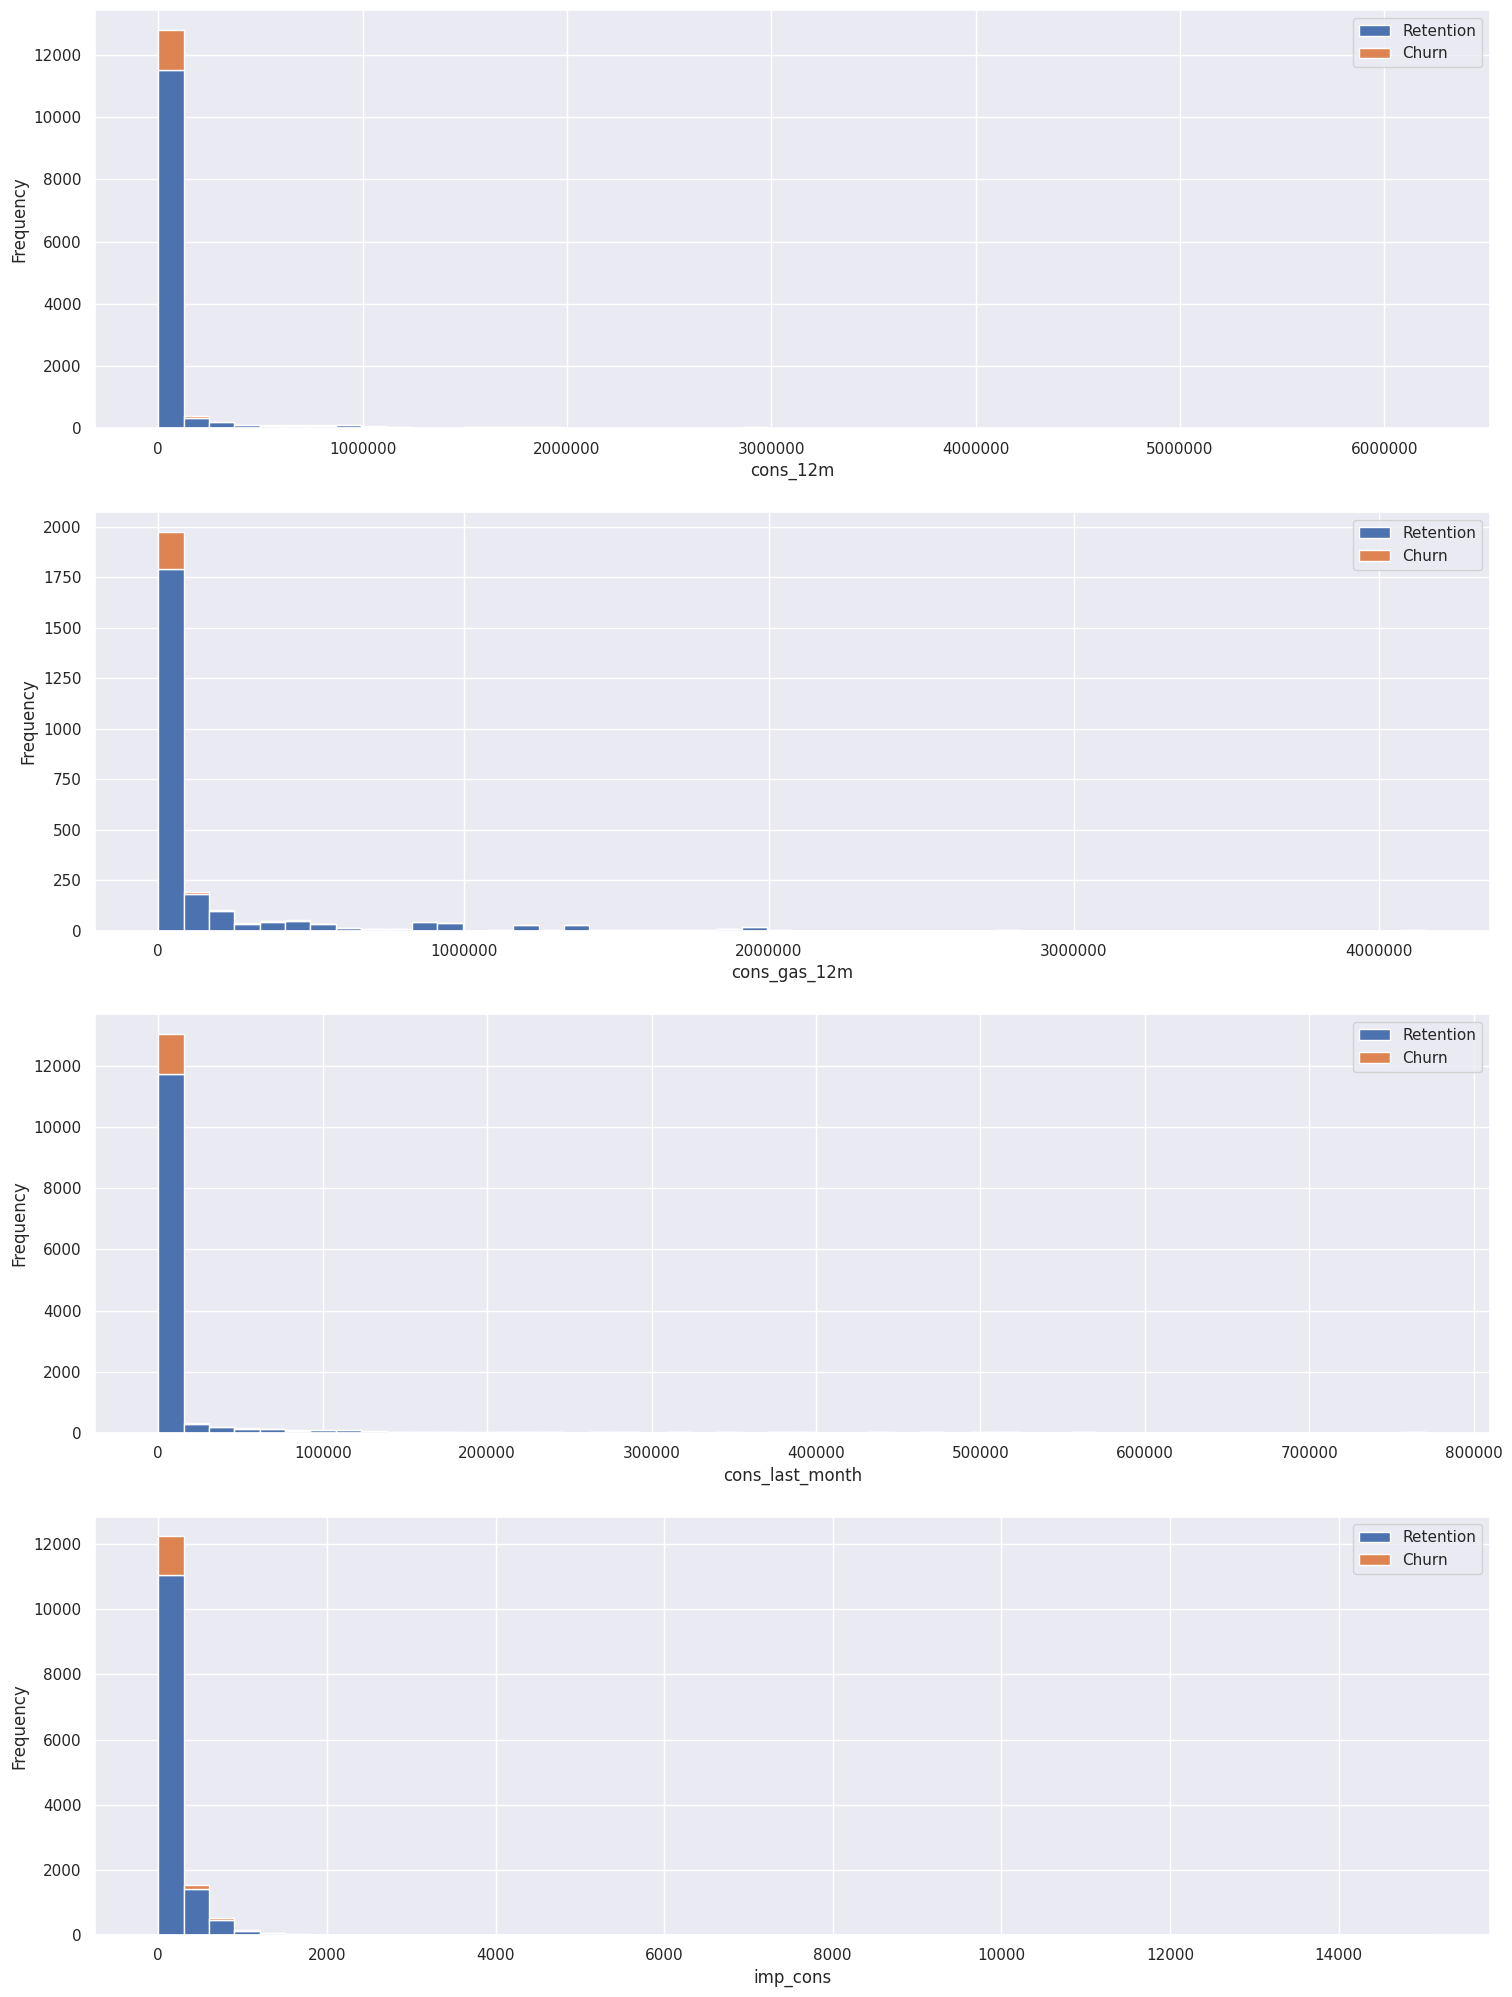

In [ ]:
fig, axs = plt.subplots(nrows=4, figsize=(18, 25))

plot_distribution(consumption, 'cons_12m', axs[0])
plot_distribution(consumption[consumption['has_gas'] == 't'], 'cons_gas_12m', axs[1])
plot_distribution(consumption, 'cons_last_month', axs[2])
plot_distribution(consumption, 'imp_cons', axs[3])

Clearly, the consumption data is highly positively skewed, presenting a very long right-tail towards the higher values of the distribution. The values on the higher and lower end of the distribution are likely to be outliers. We can use a standard plot to visualise the outliers in more detail. A boxplot is a standardized way of displaying the distribution based on a five number summary:
- Minimum
- First quartile (Q1)
- Median
- Third quartile (Q3)
- Maximum

It can reveal outliers and what their values are. It can also tell us if our data is symmetrical, how tightly our data is grouped and if/how our data is skewed.

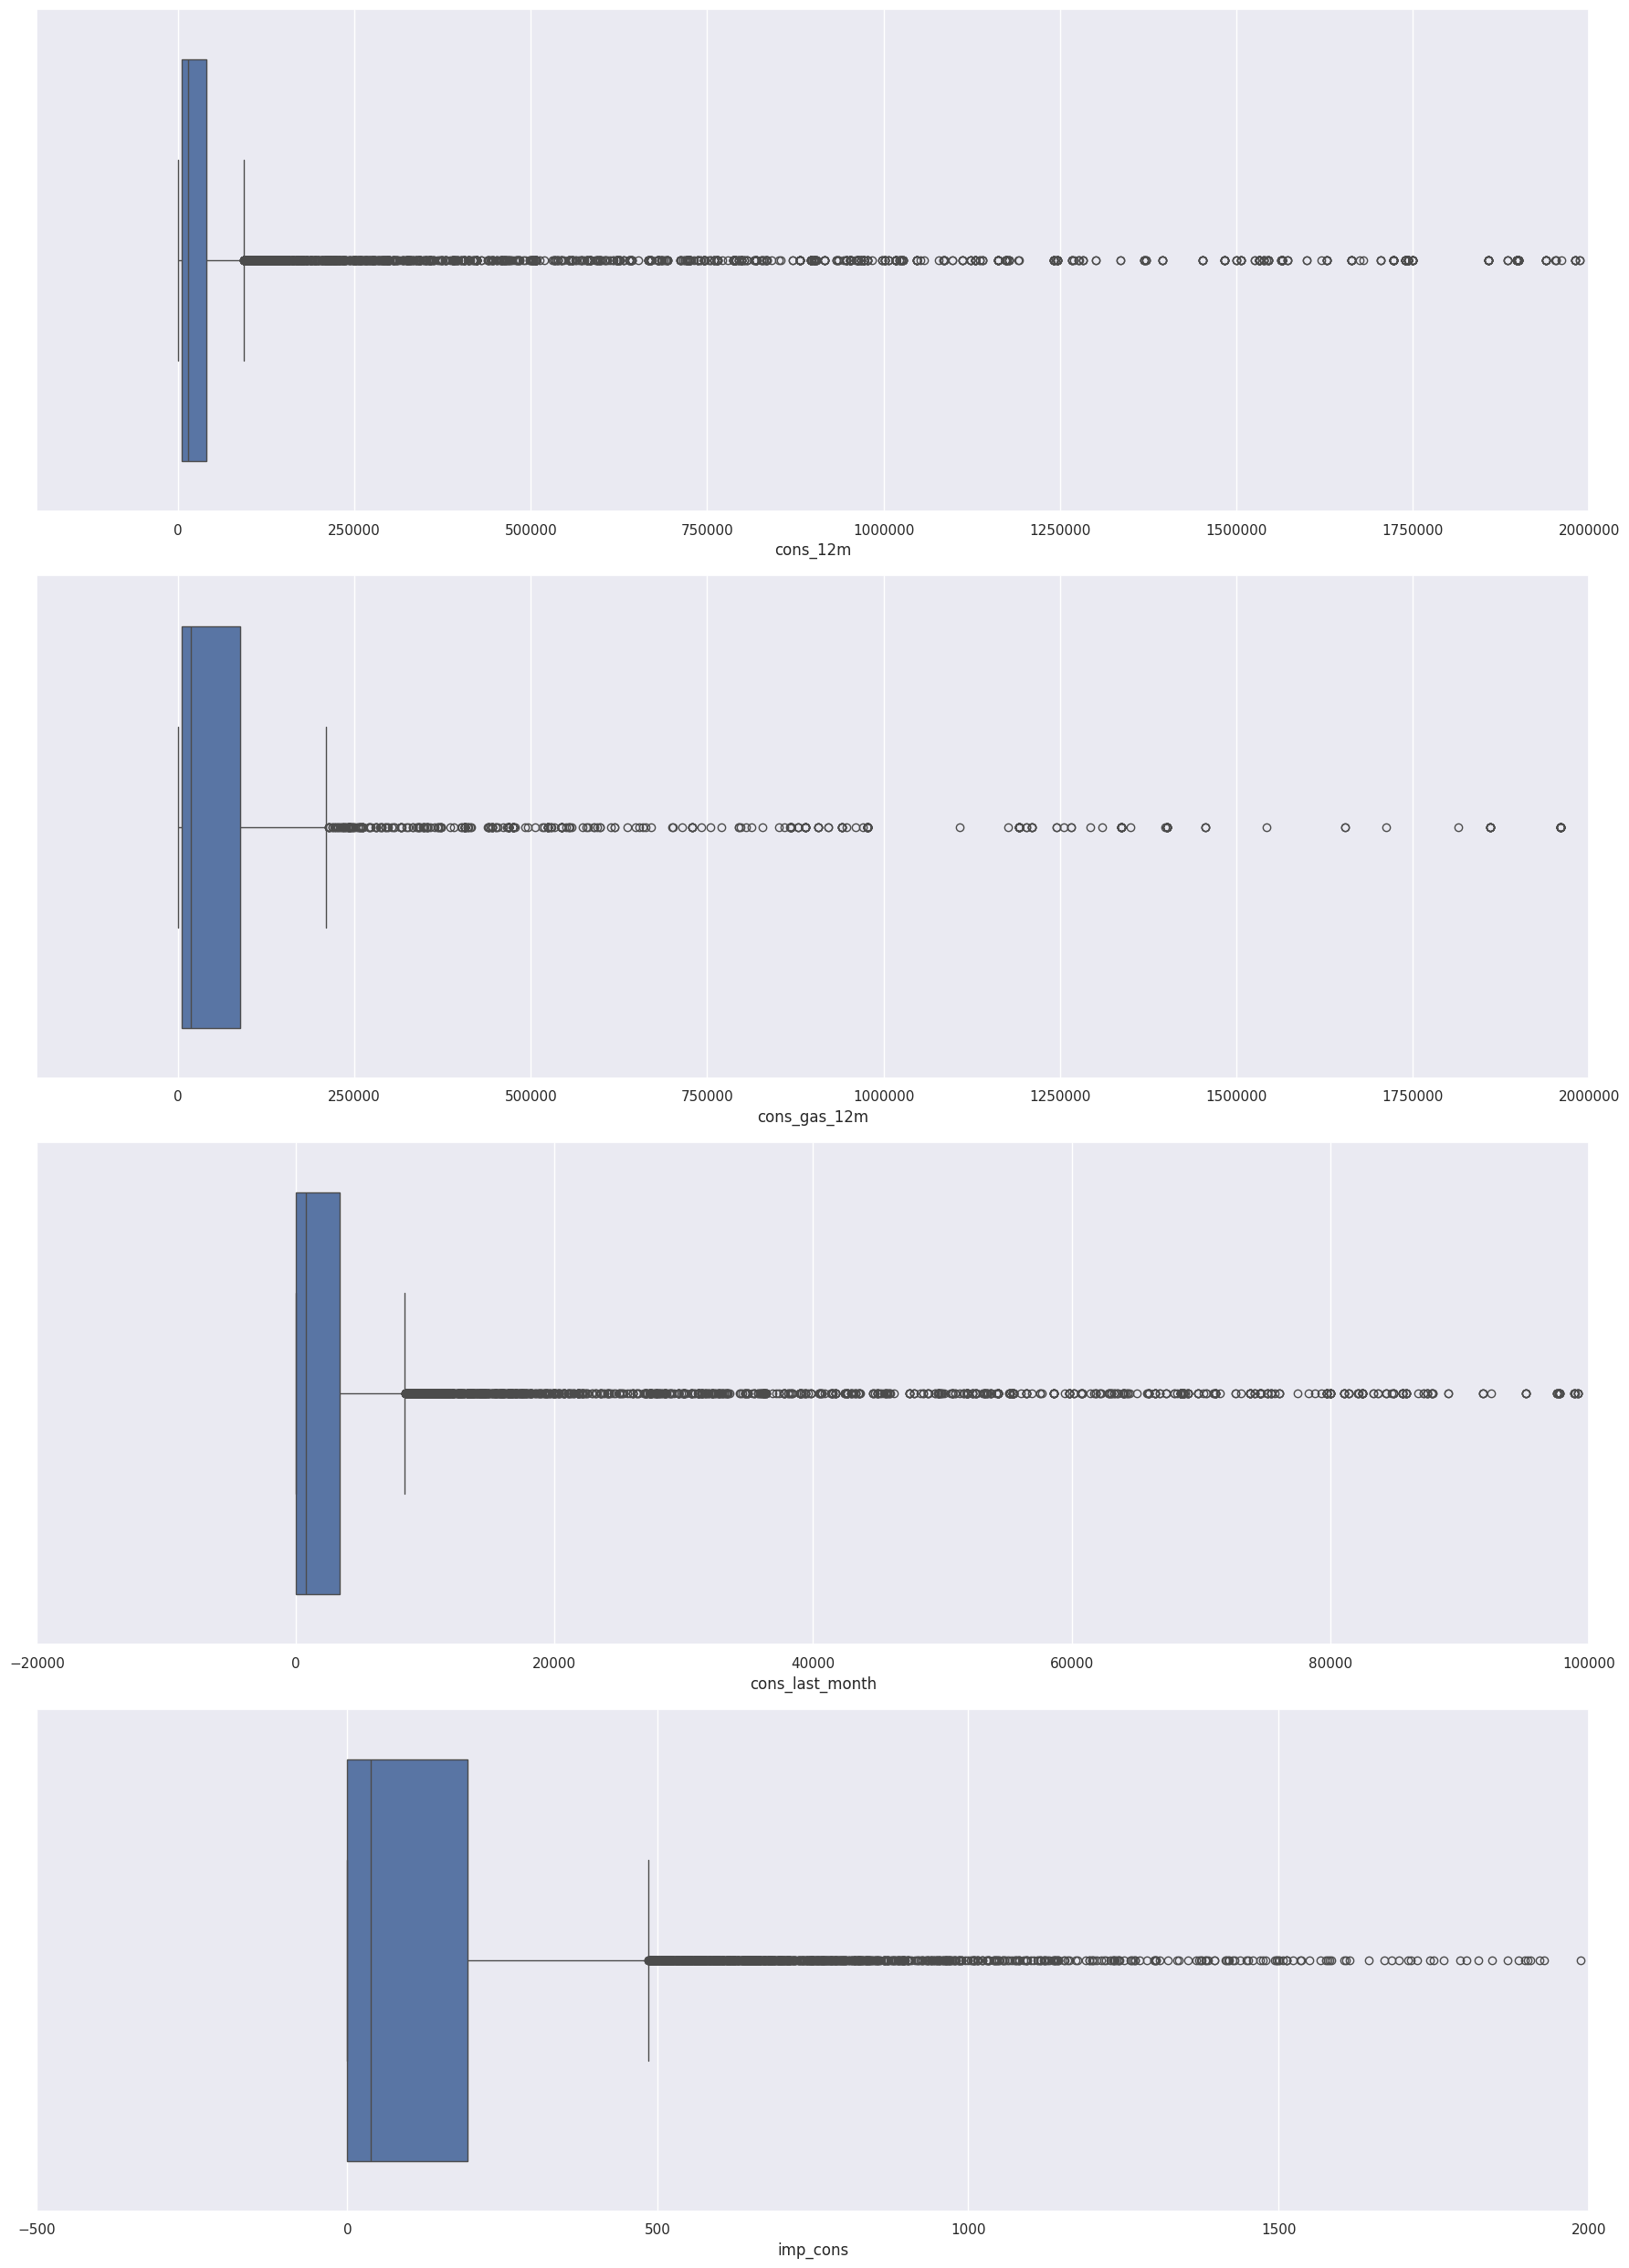

In [ ]:
fig, axs = plt.subplots(nrows=4, figsize=(18,25))

# Plot histogram
sns.boxplot(x=consumption["cons_12m"], ax=axs[0])
sns.boxplot(x=consumption[consumption["has_gas"] == "t"]["cons_gas_12m"], ax=axs[1])
sns.boxplot(x=consumption["cons_last_month"], ax=axs[2])
sns.boxplot(x=consumption["imp_cons"], ax=axs[3])

# Set x-axis limit for each subplot
axs[0].set_xlim(-200000, 2000000)
axs[1].set_xlim(-200000, 2000000)
axs[2].set_xlim(-20000, 100000)
axs[3].set_xlim(-500, 2000)

# Remove scientific notation (optional, if needed for boxplots on x-axis)
for ax in axs:
    ax.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

### Forecast

In [ ]:
forecast = client_df[
    ["id", "forecast_cons_12m",
    "forecast_cons_year","forecast_discount_energy","forecast_meter_rent_12m",
    "forecast_price_energy_off_peak","forecast_price_energy_peak",
    "forecast_price_pow_off_peak","churn" ]]

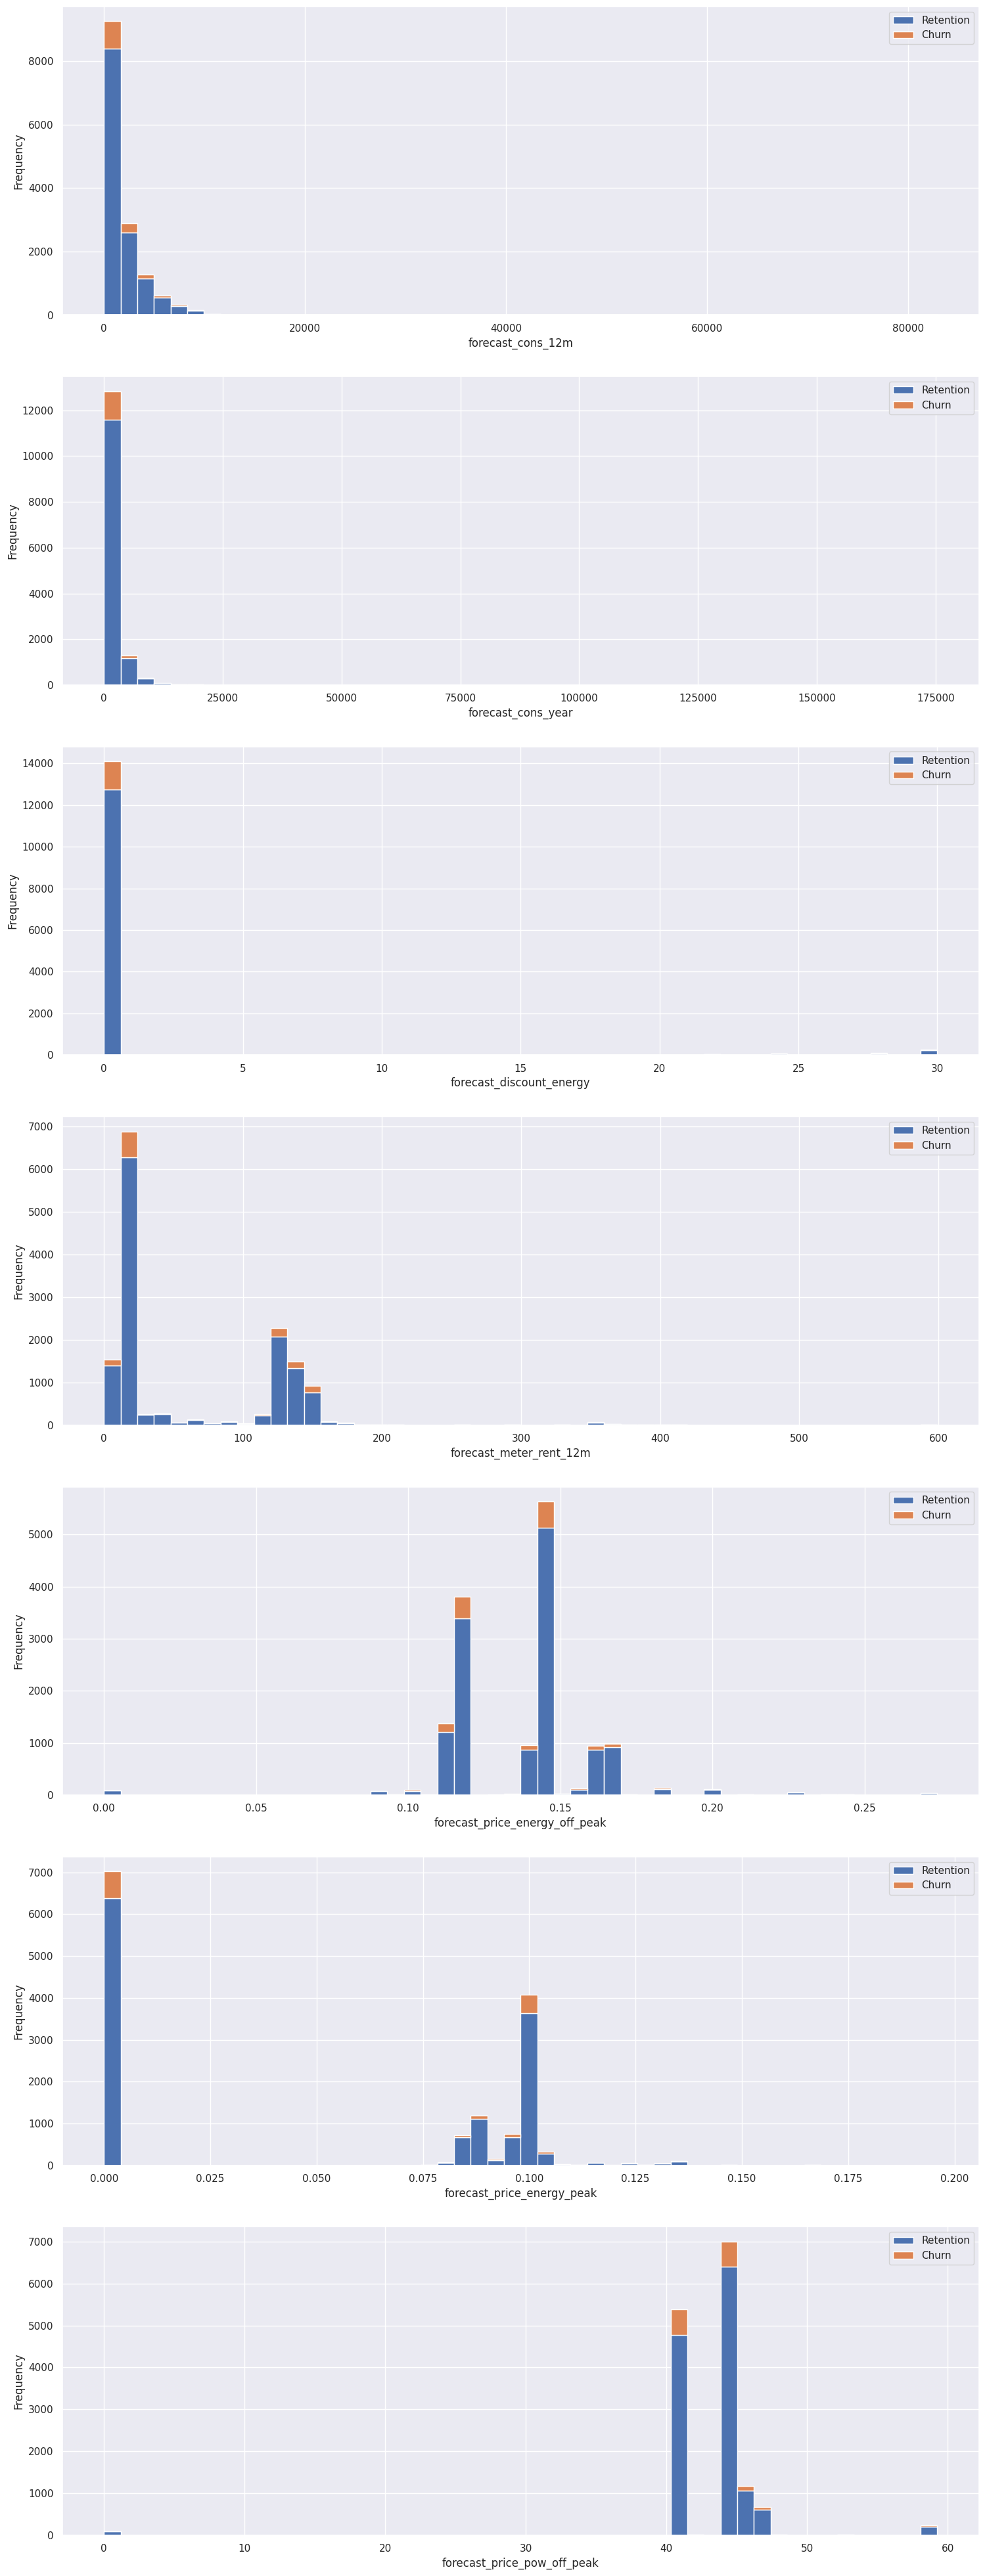

In [ ]:
fig, axs = plt.subplots(nrows=7, figsize=(18,50))

# Plot histogram
plot_distribution(client_df, "forecast_cons_12m", axs[0])
plot_distribution(client_df, "forecast_cons_year", axs[1])
plot_distribution(client_df, "forecast_discount_energy", axs[2])
plot_distribution(client_df, "forecast_meter_rent_12m", axs[3])
plot_distribution(client_df, "forecast_price_energy_off_peak", axs[4])
plot_distribution(client_df, "forecast_price_energy_peak", axs[5])
plot_distribution(client_df, "forecast_price_pow_off_peak", axs[6])

Similarly to the consumption plots, we can observe that a lot of the variables are highly positively skewed, creating a very long tail for the higher values. We will make some transformations during the next exercise to correct for this skewness.

### Contract type

In [ ]:
contract_type = client_df[['id', 'has_gas', 'churn']]
contract = contract_type.groupby([contract_type['churn'], contract_type['has_gas']])['id'].count().unstack(level=0)
contract_percentage = (contract.div(contract.sum(axis=1), axis=0) * 100).sort_values(by=[1], ascending=False)

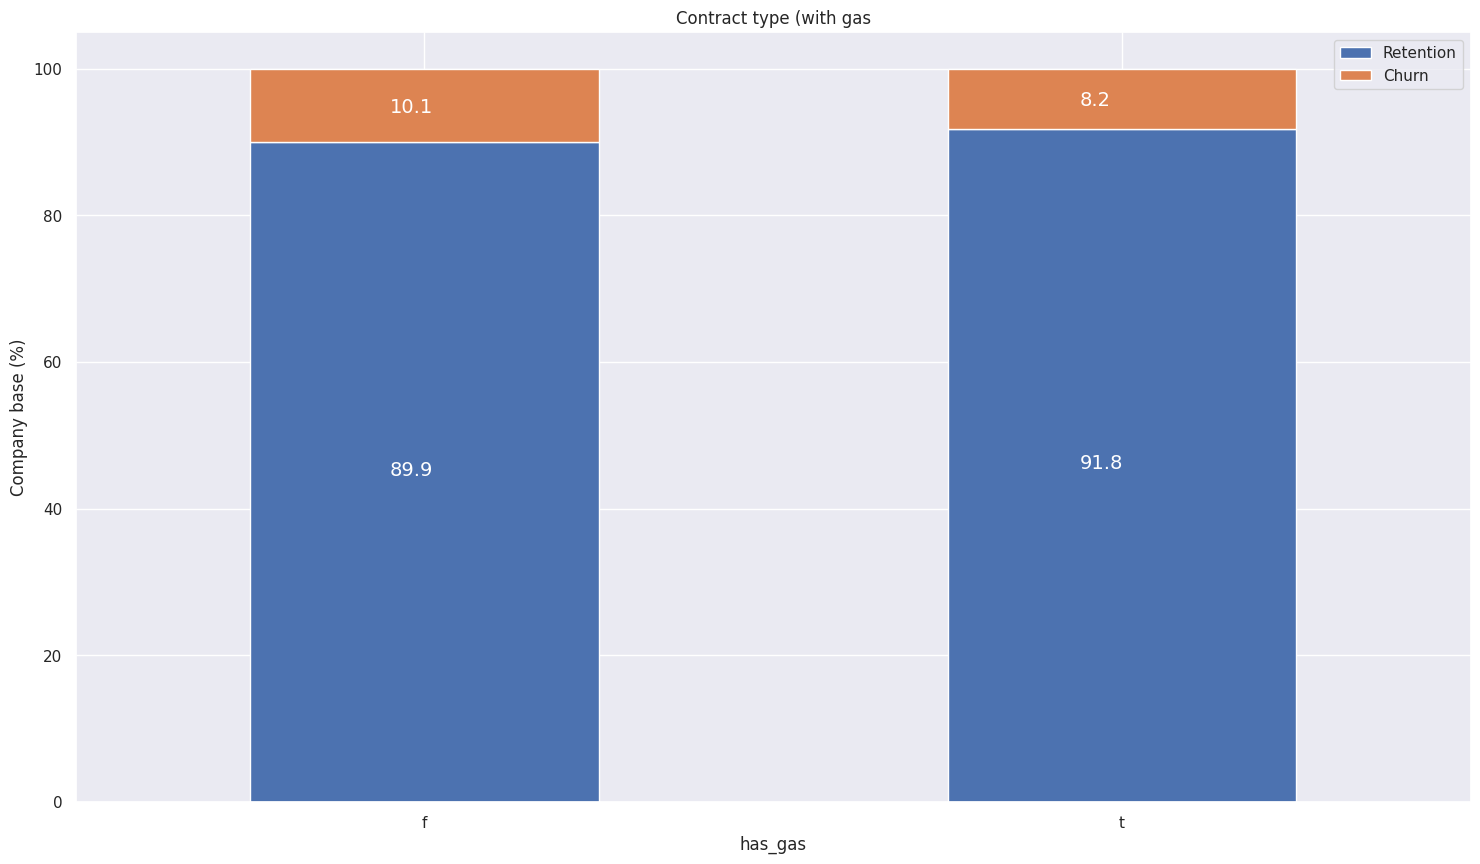

In [ ]:
plot_stacked_bars(contract_percentage, 'Contract type (with gas')

### Margins

In [ ]:
margin = client_df[['id', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'net_margin']]

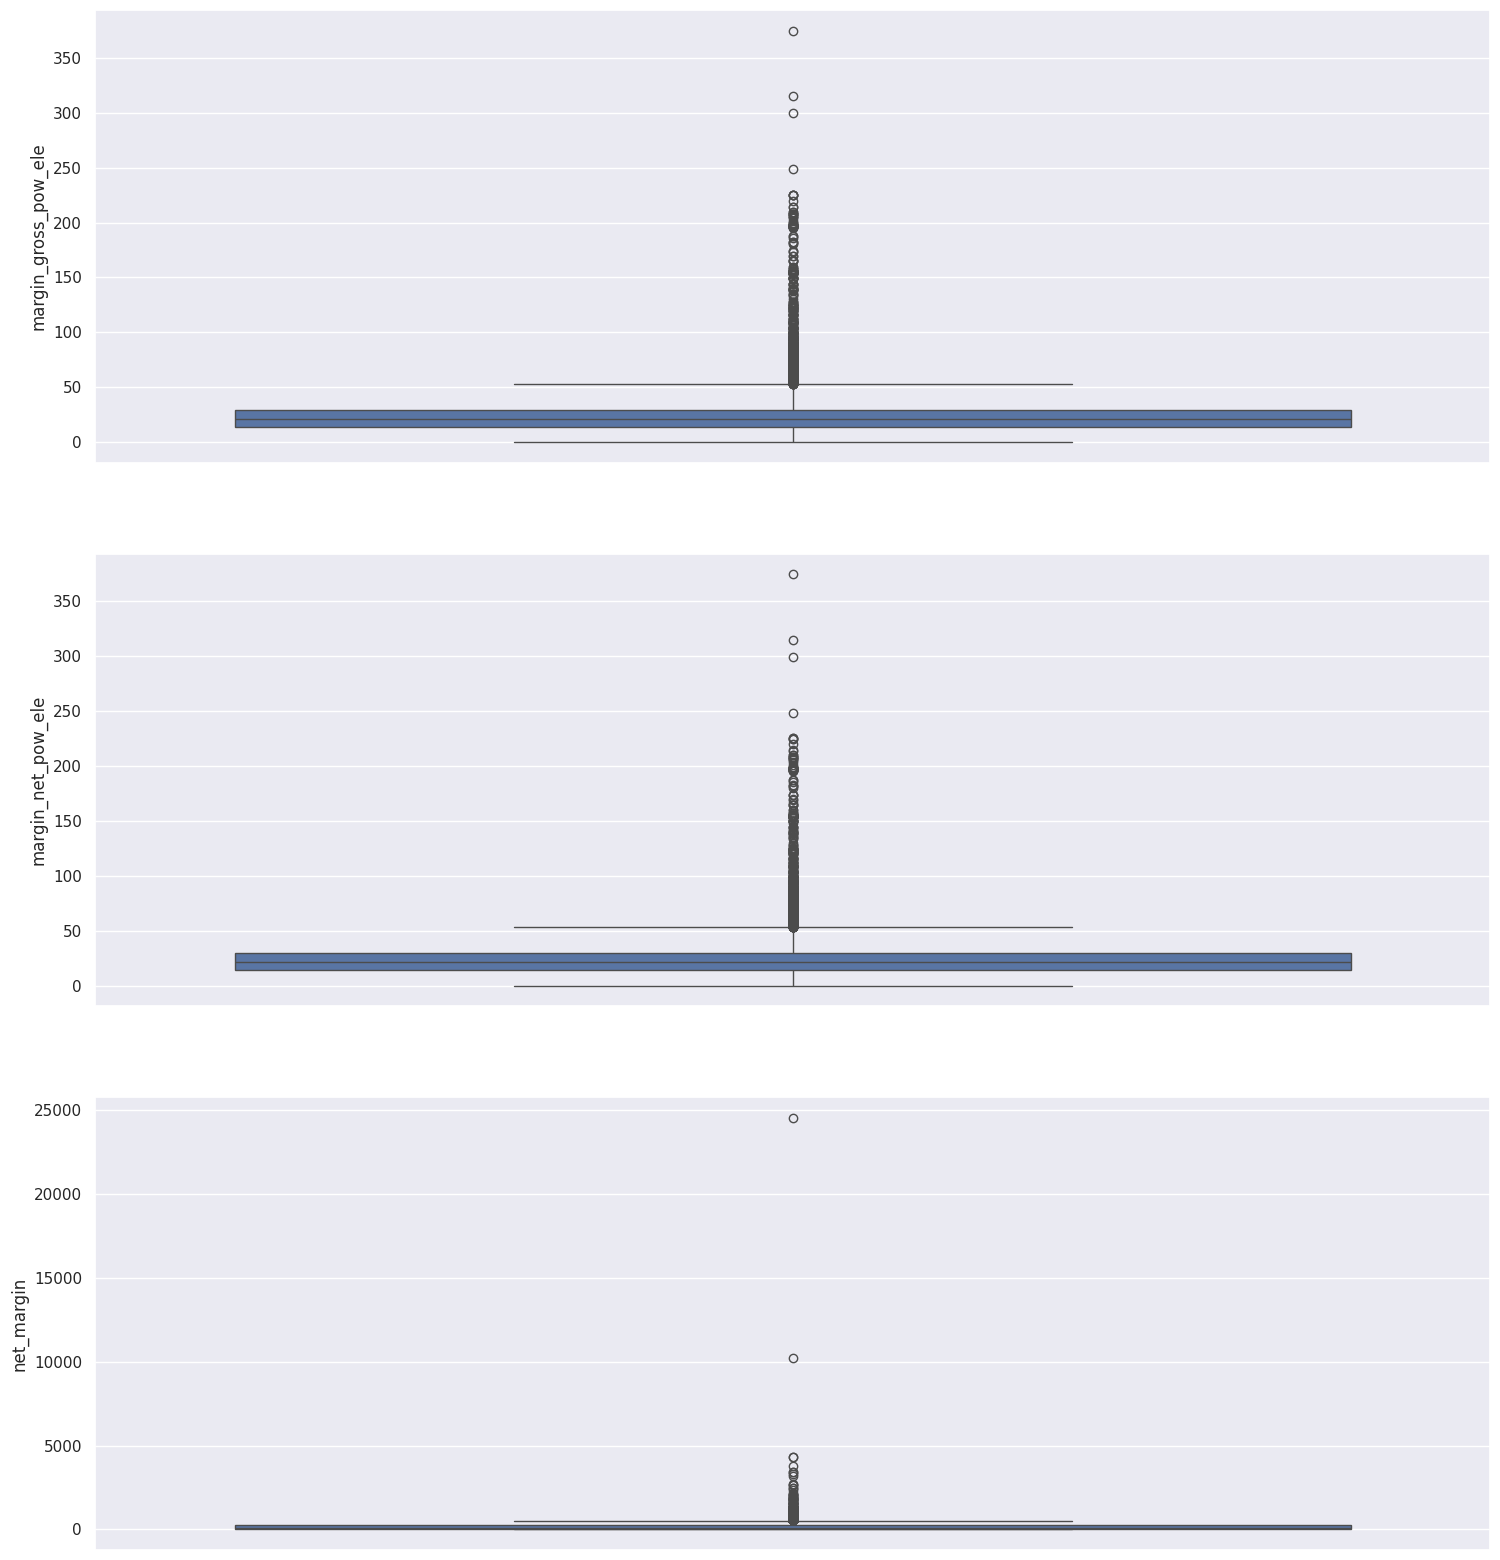

In [ ]:
fig, axs = plt.subplots(nrows=3, figsize=(18,20))
# Plot histogram
sns.boxplot(margin["margin_gross_pow_ele"], ax=axs[0])
sns.boxplot(margin["margin_net_pow_ele"],ax=axs[1])
sns.boxplot(margin["net_margin"], ax=axs[2])
# Remove scientific notation
plt.show()

We can see some outliers here as well which we will deal with in the next exercise.

### Subscribed power

In [ ]:
power = client_df[['id', 'pow_max', 'churn']]

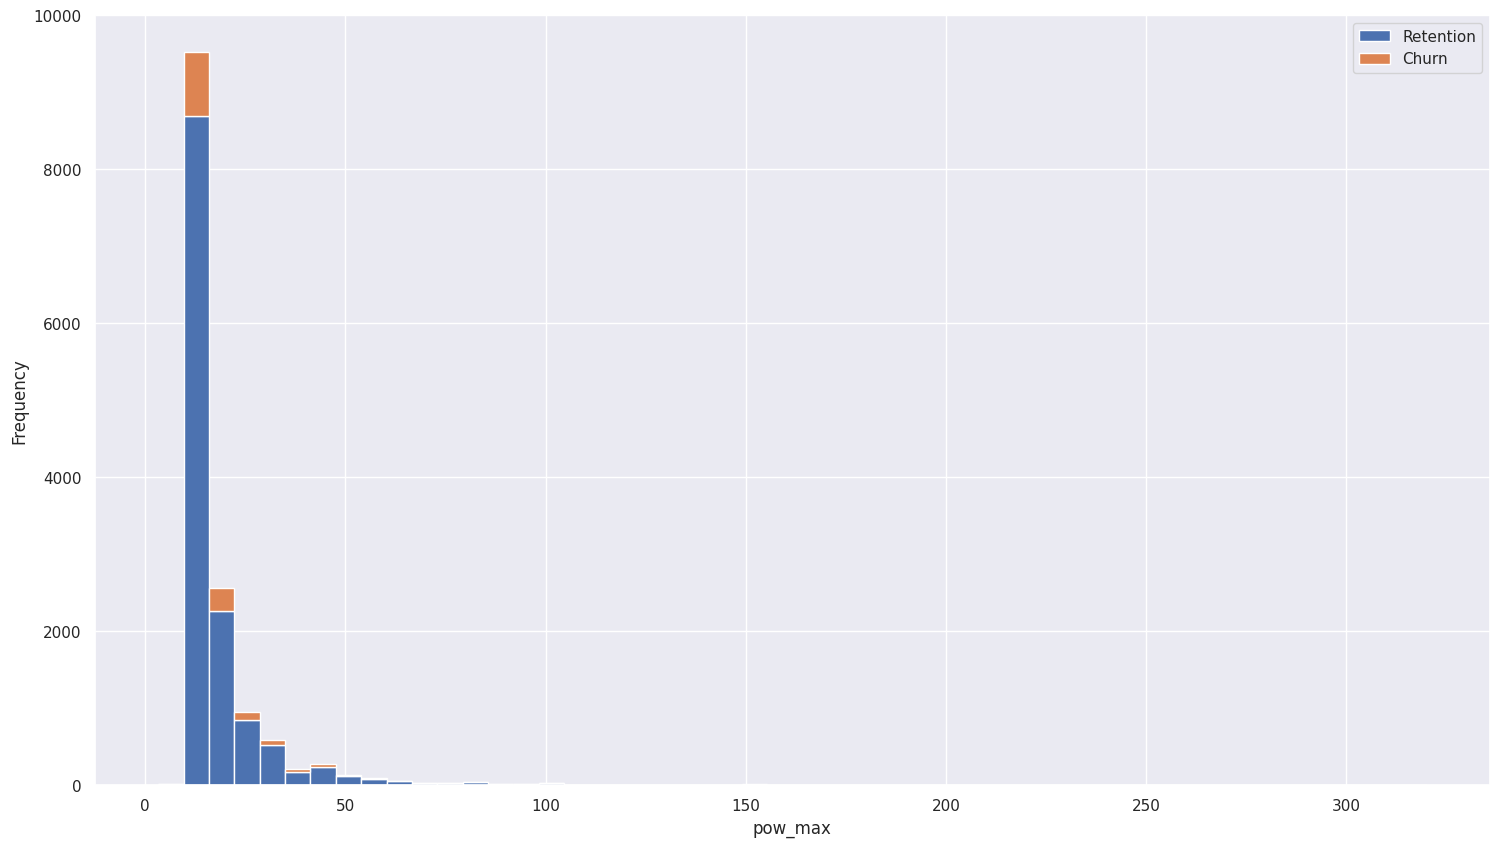

In [ ]:
fig, axs = plt.subplots(nrows=1, figsize=(18, 10))
plot_distribution(power, 'pow_max', axs)

### Other columns

In [ ]:
others = client_df[['id', 'nb_prod_act', 'num_years_antig', 'origin_up', 'churn']]
products = others.groupby([others["nb_prod_act"],others["churn"]])["id"].count().unstack(level=1)
products_percentage = (products.div(products.sum(axis=1), axis=0)*100).sort_values(by=[1], ascending=False)

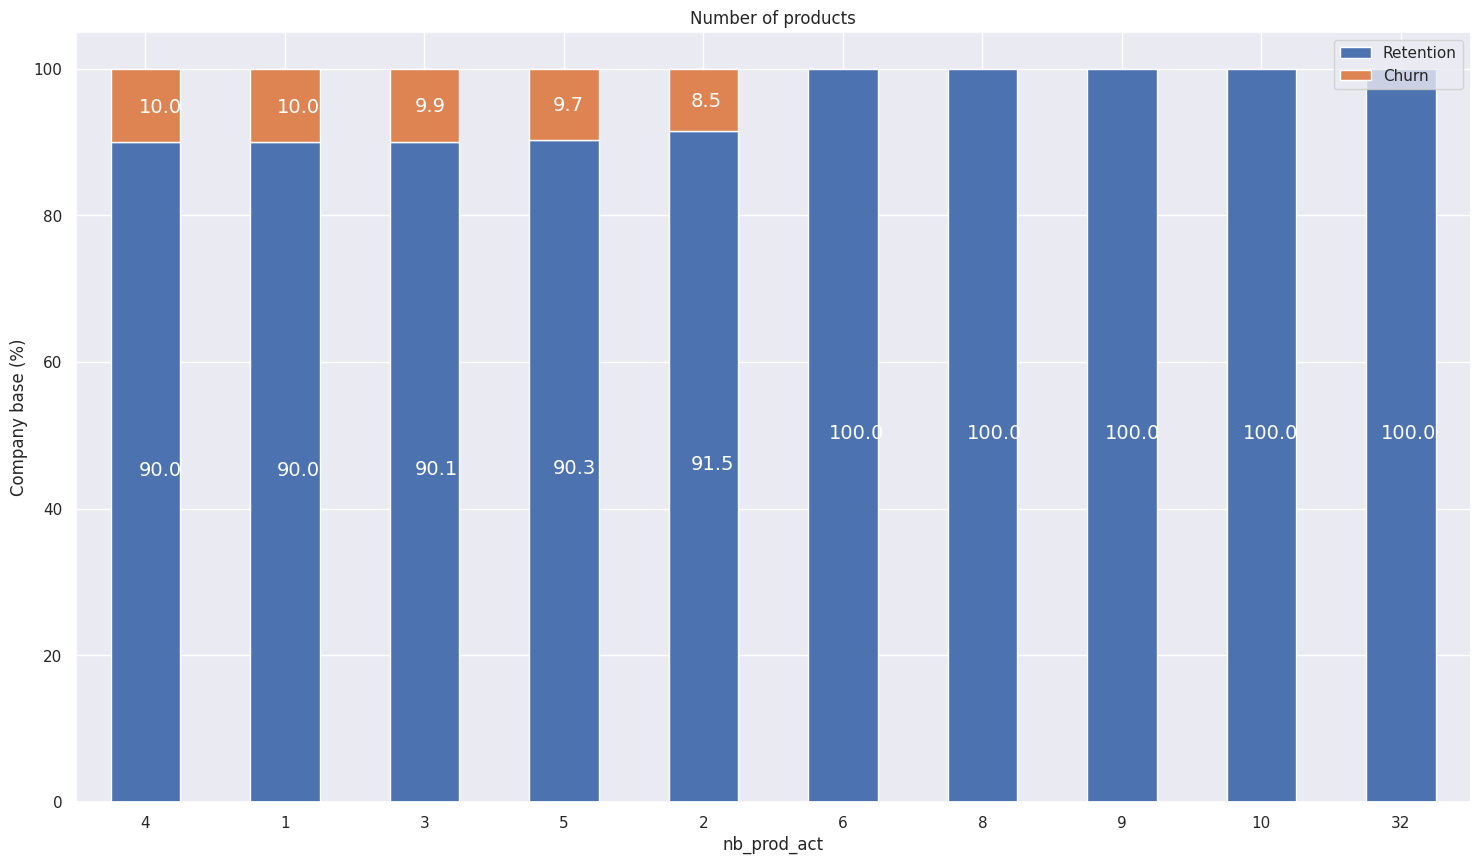

In [ ]:
plot_stacked_bars(products_percentage, "Number of products")

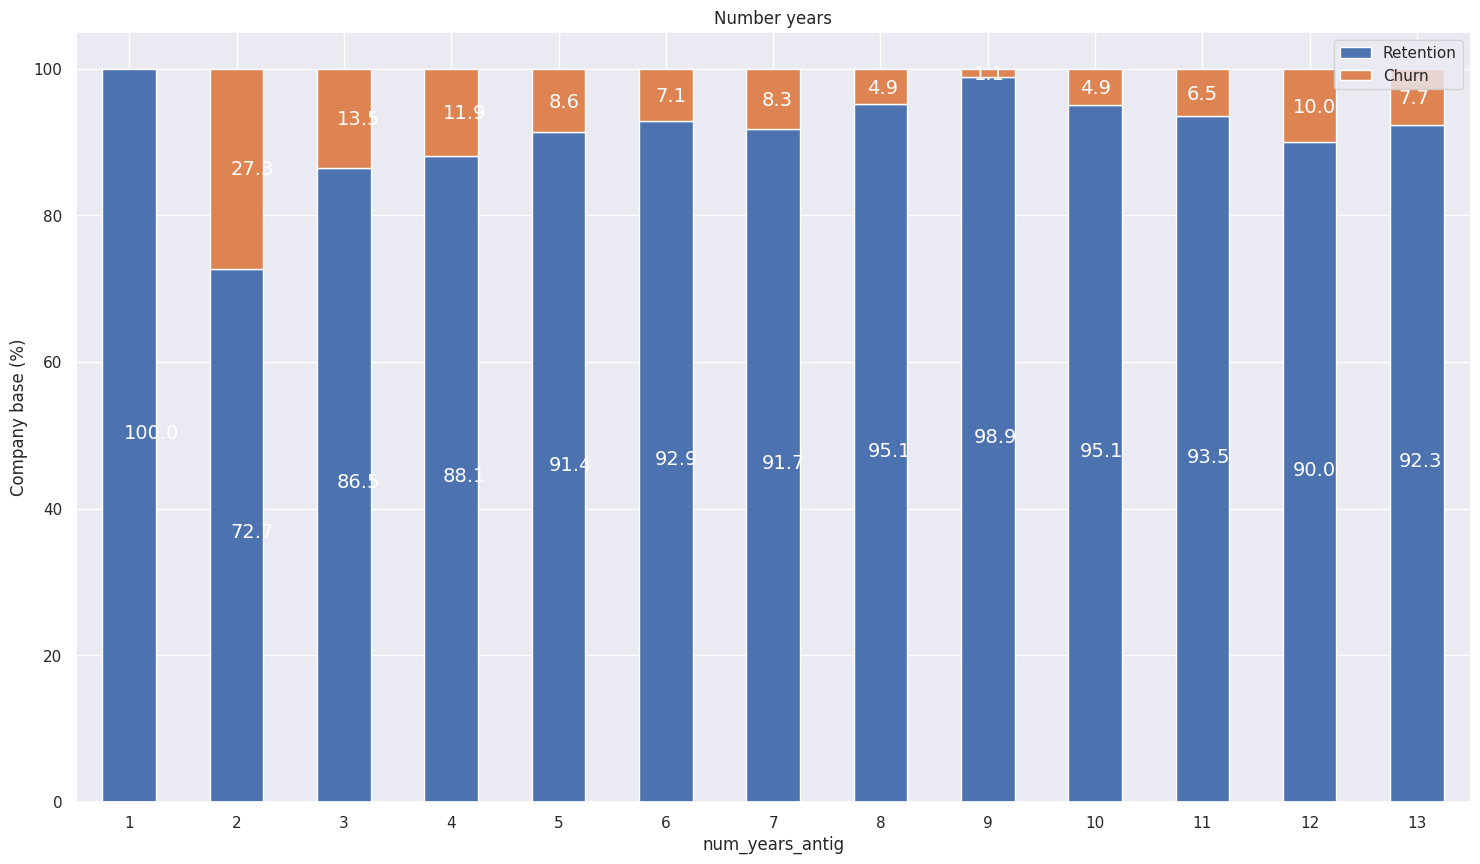

In [ ]:
years_antig = others.groupby([others["num_years_antig"],others["churn"]])["id"].count().unstack(level=1)
years_antig_percentage = (years_antig.div(years_antig.sum(axis=1), axis=0)*100)
plot_stacked_bars(years_antig_percentage, "Number years")

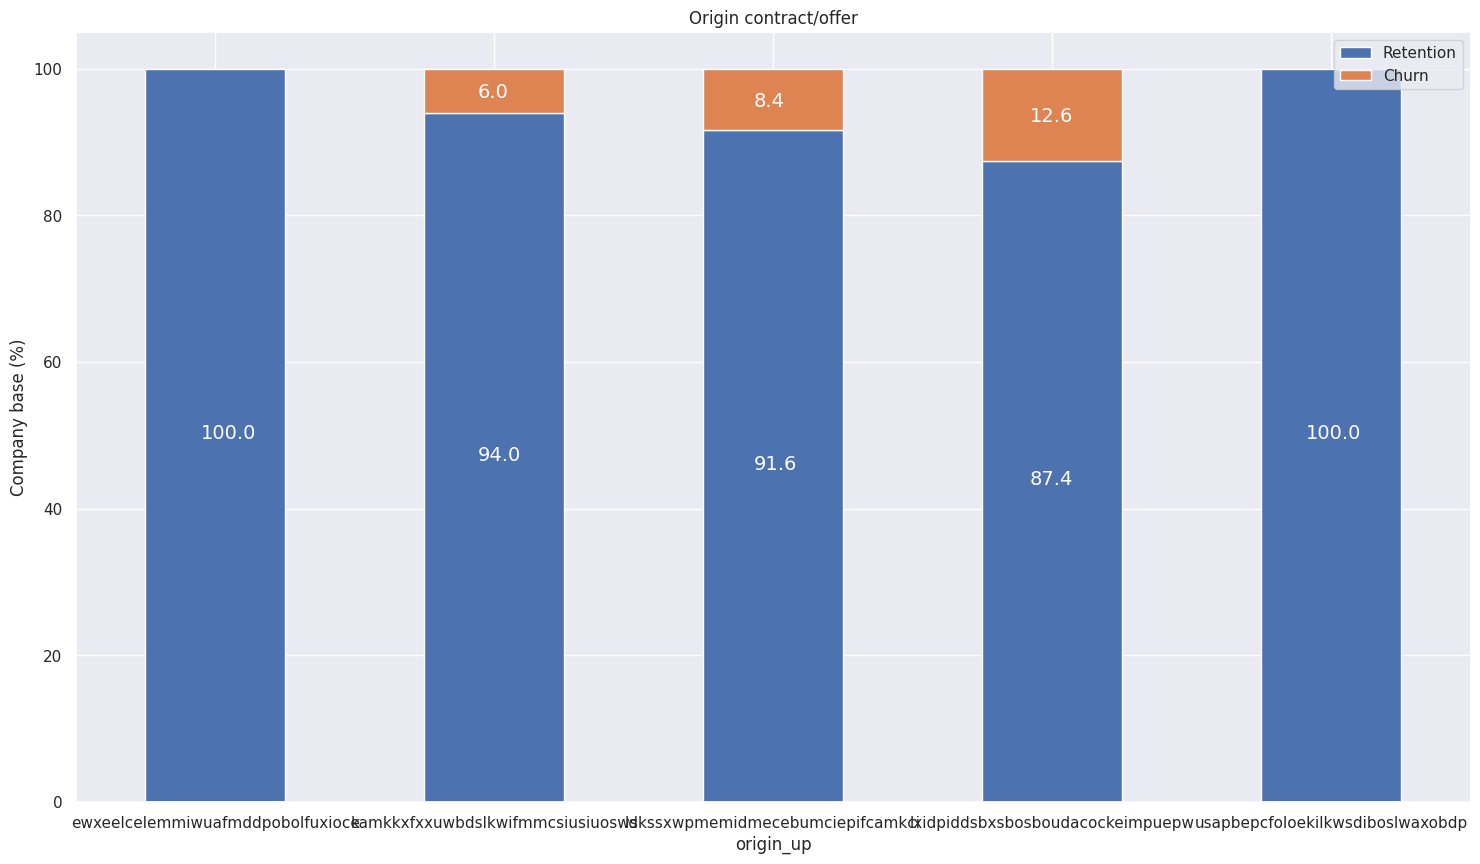

In [ ]:
origin = others.groupby([others["origin_up"],others["churn"]])["id"].count().unstack(level=1)
origin_percentage = (origin.div(origin.sum(axis=1), axis=0)*100)
plot_stacked_bars(origin_percentage, "Origin contract/offer")

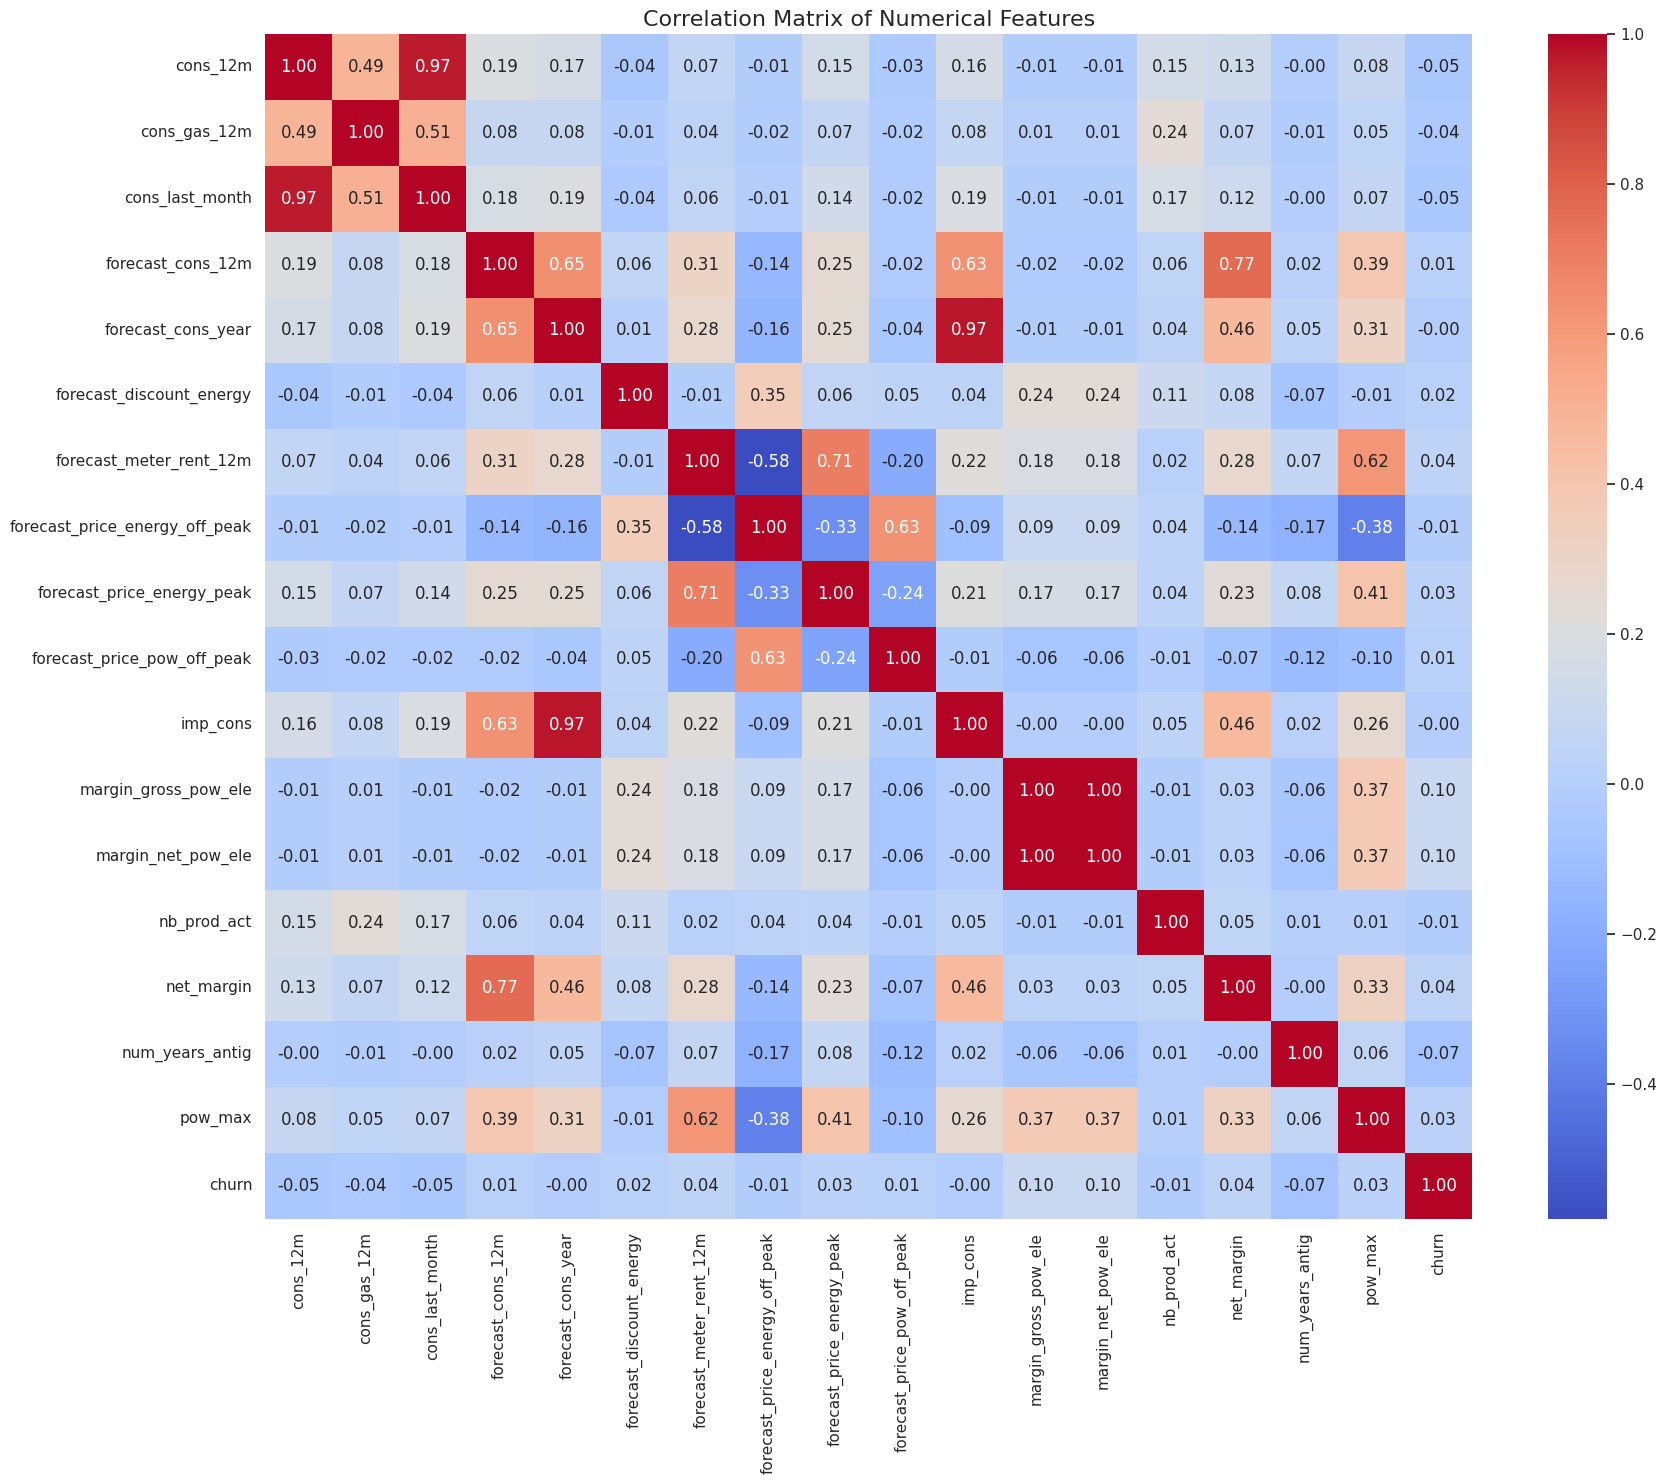

In [ ]:
plt.figure(figsize=(18, 15))
sns.heatmap(client_df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Observation: The correlation heatmap provides an overview of linear relationships between numerical features and with churn.

churn shows very low positive correlations with cons_12m, cons_gas_12m, and cons_last_month, suggesting these consumption variables have a weak linear relationship with churn.
Features like margin_gross_pow_ele and margin_net_pow_ele are highly correlated with each other, as expected.
Many features show low correlations with churn, indicating that churn might be influenced by non-linear relationships or combinations of features, or that some features are not strong individual predictors.
The overall low correlation values with churn suggest that predicting churn will likely require more complex models that can capture non-linear interactions or that feature engineering will be crucial.

## Feature Engineering: Consumption and Date-Related Features

This section focuses on creating new features derived from existing consumption and date columns in the `client_df`. These new features aim to capture more granular insights and relationships within the data, which can be valuable for downstream modeling tasks.

In [ ]:
client_df["date_activ"] = pd.to_datetime(client_df["date_activ"], format='%Y-%m-%d')
client_df["date_end"] = pd.to_datetime(client_df["date_end"], format='%Y-%m-%d')
client_df["date_modif_prod"] = pd.to_datetime(client_df["date_modif_prod"], format='%Y-%m-%d')
client_df["date_renewal"] = pd.to_datetime(client_df["date_renewal"], format='%Y-%m-%d')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d')

In [ ]:
# Calculate time from product modification to renewal
client_df['modif_to_renewal_duration'] = (client_df['date_renewal'] - client_df['date_modif_prod']).dt.days

# Calculate time from activation to product modification
client_df['activ_to_modif_duration'] = (client_df['date_modif_prod'] - client_df['date_activ']).dt.days

# Calculate days remaining until contract end from a reference date (e.g., 2016-01-01)
reference_date = pd.to_datetime('2016-01-01')
client_df['days_until_end'] = (client_df['date_end'] - reference_date).dt.days

print("Additional date-based features created.")
display(client_df[['id', 'modif_to_renewal_duration', 'activ_to_modif_duration', 'days_until_end']].head())

Additional date-based features created.


,id,modif_to_renewal_duration,activ_to_modif_duration,days_until_end
0,24011ae4ebbe3035111d65fa7c15bc57,-131,869,166
1,d29c2c54acc38ff3c0614d0a653813dd,2201,0,242
2,764c75f661154dac3a6c254cd082ea7d,1827,0,106
3,bba03439a292a1e166f80264c16191cb,1827,0,89
4,149d57cf92fc41cf94415803a877cb4b,1881,0,66


In [ ]:
# Calculate contract duration in days
client_df['contract_duration'] = (client_df['date_end'] - client_df['date_activ']).dt.days

# Calculate days since activation until a reference date (e.g., end of 2015, which seems to be the last full year of data in many columns)
# Using 2016-01-01 as a reference to ensure all dates are covered without looking into the future
reference_date = pd.to_datetime('2016-01-01')
client_df['days_since_activ'] = (reference_date - client_df['date_activ']).dt.days
client_df['days_since_modif_prod'] = (reference_date - client_df['date_modif_prod']).dt.days
client_df['days_since_renewal'] = (reference_date - client_df['date_renewal']).dt.days

# Extract year, month, and day of week from relevant dates
client_df['activ_year'] = client_df['date_activ'].dt.year
client_df['activ_month'] = client_df['date_activ'].dt.month
client_df['activ_dayofweek'] = client_df['date_activ'].dt.dayofweek

client_df['end_year'] = client_df['date_end'].dt.year
client_df['end_month'] = client_df['date_end'].dt.month
client_df['end_dayofweek'] = client_df['date_end'].dt.dayofweek

print("New date-based features created.")
display(client_df[['id', 'contract_duration', 'days_since_activ', 'days_since_modif_prod', 'days_since_renewal', 'activ_year', 'activ_month', 'end_year']].head())

New date-based features created.


,id,contract_duration,days_since_activ,days_since_modif_prod,days_since_renewal,activ_year,activ_month,end_year
0,24011ae4ebbe3035111d65fa7c15bc57,1096,930,61,192,2013,6,2016
1,d29c2c54acc38ff3c0614d0a653813dd,2566,2324,2324,123,2009,8,2016
2,764c75f661154dac3a6c254cd082ea7d,2192,2086,2086,259,2010,4,2016
3,bba03439a292a1e166f80264c16191cb,2192,2103,2103,276,2010,3,2016
4,149d57cf92fc41cf94415803a877cb4b,2245,2179,2179,298,2010,1,2016


In [ ]:
# Define a reference date for 'days since' and 'days until' calculations
reference_date = client_df['date_end'].max() # Using the latest date_end in the dataset

# 1. Consumption-related features
client_df['cons_last_month_to_12m_ratio'] = client_df['cons_last_month'] / client_df['cons_12m']
client_df['cons_12m_to_forecast_12m_ratio'] = client_df['cons_12m'] / client_df['forecast_cons_12m']
client_df['cons_12m_per_day'] = client_df['cons_12m'] / 365
client_df['cons_gas_12m_per_day'] = client_df['cons_gas_12m'] / 365

# Handle potential division by zero for ratio features
client_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Simple Date Features
client_df['activ_year'] = client_df['date_activ'].dt.year
client_df['activ_month'] = client_df['date_activ'].dt.month
client_df['activ_dayofweek'] = client_df['date_activ'].dt.dayofweek

client_df['end_year'] = client_df['date_end'].dt.year
client_df['end_month'] = client_df['date_end'].dt.month
client_df['end_dayofweek'] = client_df['date_end'].dt.dayofweek

# 3. Duration Features
client_df['contract_duration'] = (client_df['date_end'] - client_df['date_activ']).dt.days
client_df['modif_to_renewal_duration'] = (client_df['date_renewal'] - client_df['date_modif_prod']).dt.days
client_df['activ_to_modif_duration'] = (client_df['date_modif_prod'] - client_df['date_activ']).dt.days

# 4. Relative Date Features (using reference_date)
client_df['days_since_activ'] = (reference_date - client_df['date_activ']).dt.days
client_df['days_since_modif_prod'] = (reference_date - client_df['date_modif_prod']).dt.days
client_df['days_since_renewal'] = (reference_date - client_df['date_renewal']).dt.days
client_df['days_until_end'] = (client_df['date_end'] - reference_date).dt.days

print("New consumption and date-related features created in client_df.")
print("Updated client_df head:")
display(client_df.head())

New consumption and date-related features created in client_df.
Updated client_df head:


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,activ_year,activ_month,activ_dayofweek,end_year,end_month,end_dayofweek,cons_last_month_to_12m_ratio,cons_12m_to_forecast_12m_ratio,cons_12m_per_day,cons_gas_12m_per_day
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,2013,6,5,2016,6,2,NaN,NaN,0.000000,150.536986
1,d29c2c54acc38ff3c0614d0a653813dd,NaN,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,2009,8,4,2016,8,1,0.00000,24.532772,12.767123,0.000000
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,2010,4,4,2016,4,5,0.00000,11.342786,1.490411,0.000000
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,2010,3,1,2016,3,2,0.00000,6.598900,4.339726,0.000000
4,149d57cf92fc41cf94415803a877cb4b,NaN,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,2010,1,2,2016,3,0,0.11887,9.927089,12.123288,0.000000


In [ ]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power']]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


In [ ]:
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001


### Merging the `diff` dataframe

### Consumption-based Features

In [ ]:
# Ratio of last month's consumption to 12-month consumption
client_df['cons_last_month_to_12m_ratio'] = client_df['cons_last_month'] / client_df['cons_12m']
client_df['cons_last_month_to_12m_ratio'] = client_df['cons_last_month_to_12m_ratio'].replace([float('inf'), -float('inf')], 0).fillna(0)

# Ratio of 12-month consumption to forecasted 12-month consumption
client_df['cons_12m_to_forecast_12m_ratio'] = client_df['cons_12m'] / client_df['forecast_cons_12m']
client_df['cons_12m_to_forecast_12m_ratio'] = client_df['cons_12m_to_forecast_12m_ratio'].replace([float('inf'), -float('inf')], 0).fillna(0)

# Calculate consumption per day for 12 months (to account for different contract durations)
client_df['cons_12m_per_day'] = client_df['cons_12m'] / 365

# Calculate gas consumption per day for 12 months
client_df['cons_gas_12m_per_day'] = client_df['cons_gas_12m'] / 365

print("New consumption-based features created.")
display(client_df[['id', 'cons_last_month_to_12m_ratio', 'cons_12m_to_forecast_12m_ratio', 'cons_12m_per_day', 'cons_gas_12m_per_day']].head())

New consumption-based features created.


,id,cons_last_month_to_12m_ratio,cons_12m_to_forecast_12m_ratio,cons_12m_per_day,cons_gas_12m_per_day
0,24011ae4ebbe3035111d65fa7c15bc57,0.00000,0.000000,0.000000,150.536986
1,d29c2c54acc38ff3c0614d0a653813dd,0.00000,24.532772,12.767123,0.000000
2,764c75f661154dac3a6c254cd082ea7d,0.00000,11.342786,1.490411,0.000000
3,bba03439a292a1e166f80264c16191cb,0.00000,6.598900,4.339726,0.000000
4,149d57cf92fc41cf94415803a877cb4b,0.11887,9.927089,12.123288,0.000000


In [ ]:
# Remove 'offpeak_diff_dec_january_energy' and 'offpeak_diff_dec_january_power' from client_df if they exist
for col_to_drop in ['offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']:
    if col_to_drop in client_df.columns:
        client_df = client_df.drop(columns=[col_to_drop])

# Merge the 'diff' dataframe into the main 'client_df' dataframe
client_df = pd.merge(client_df, diff, on='id', how='left')

print("Merged 'offpeak_diff_dec_january_energy' and 'offpeak_diff_dec_january_power' features.")
display(client_df[['id', 'offpeak_diff_dec_january_energy', 'offpeak_diff_dec_january_power']].head())

Merged 'offpeak_diff_dec_january_energy' and 'offpeak_diff_dec_january_power' features.


,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power
0,24011ae4ebbe3035111d65fa7c15bc57,0.020057,3.700961
1,d29c2c54acc38ff3c0614d0a653813dd,-0.003767,0.177779
2,764c75f661154dac3a6c254cd082ea7d,-0.004670,0.177779
3,bba03439a292a1e166f80264c16191cb,-0.004547,0.177779
4,149d57cf92fc41cf94415803a877cb4b,-0.006192,0.162916


## Feature Engineering: Price-Related Features

This section focuses on creating new features derived from the `price_df`. These features capture price variations and differences over specific periods, which can be crucial for understanding customer behavior related to pricing.

#### Aggregate Price Data:
Aggregate the `price_df` by `id` to get a single average value for each price component for each client.


**Reasoning**:
I will select the specified price columns, group the `price_df` by 'id', calculate the mean for each price component, store it in `mean_prices`, and then display the first 5 rows to verify the aggregation, as per the instructions.



In [ ]:
selected_price_columns = ['id', 'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix']

mean_prices = price_df[selected_price_columns].groupby('id').mean().reset_index()

print("First 5 rows of aggregated mean prices:")
display(mean_prices.head())

First 5 rows of aggregated mean prices:


,id,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,0002203ffbb812588b632b9e628cc38d,0.124338,0.103794,0.073160,40.701732,24.421038,16.280694
1,0004351ebdd665e6ee664792efc4fd13,0.146426,0.000000,0.000000,44.385450,0.000000,0.000000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.181558,0.000000,0.000000,45.319710,0.000000,0.000000
3,0010ee3855fdea87602a5b7aba8e42de,0.118757,0.098292,0.069032,40.647427,24.388455,16.258971
4,00114d74e963e47177db89bc70108537,0.147926,0.000000,0.000000,44.266930,0.000000,0.000000


---

## Average price changes across periods

We can now enhance the feature that our colleague made by calculating the average price changes across individual periods, instead of the entire year.

In [ ]:
# Aggregate average prices per period by company
mean_prices = price_df.groupby(['id']).agg({
    'price_off_peak_var': 'mean',
    'price_peak_var': 'mean',
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'
}).reset_index()

In [ ]:
# Calculate the mean difference between consecutive periods
mean_prices['off_peak_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_peak_var']
mean_prices['peak_mid_peak_var_mean_diff'] = mean_prices['price_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_mid_peak_var_mean_diff'] = mean_prices['price_off_peak_var'] - mean_prices['price_mid_peak_var']
mean_prices['off_peak_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_peak_fix']
mean_prices['peak_mid_peak_fix_mean_diff'] = mean_prices['price_peak_fix'] - mean_prices['price_mid_peak_fix']
mean_prices['off_peak_mid_peak_fix_mean_diff'] = mean_prices['price_off_peak_fix'] - mean_prices['price_mid_peak_fix']

In [ ]:
columns = [
    'id',
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff',
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff',
    'peak_mid_peak_fix_mean_diff',
    'off_peak_mid_peak_fix_mean_diff'
]
client_df = pd.merge(client_df, mean_prices[columns], on='id')
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,cons_12m_per_day,cons_gas_12m_per_day,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000000,150.536986,0.020057,3.700961,0.024038,0.034219,0.058257,18.590255,7.450670,26.040925
1,d29c2c54acc38ff3c0614d0a653813dd,NaN,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,12.767123,0.000000,-0.003767,0.177779,0.142485,0.007124,0.149609,44.311375,0.000000,44.311375
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,1.490411,0.000000,-0.004670,0.177779,0.082090,0.088421,0.170512,44.385450,0.000000,44.385450
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,4.339726,0.000000,-0.004547,0.177779,0.151210,0.000000,0.151210,44.400265,0.000000,44.400265
4,149d57cf92fc41cf94415803a877cb4b,NaN,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,12.123288,0.000000,-0.006192,0.162916,0.020536,0.030773,0.051309,16.275263,8.137629,24.412893


This feature may be useful because it adds more granularity to the existing feature that our colleague found to be useful. Instead of looking at differences across an entire year, we have now created features that look at mean average price differences across different time periods (`off_peak`, `peak`, `mid_peak`). The dec-jan feature may reveal macro patterns that occur over an entire year, whereas inter-time-period features may reveal patterns on a micro scale between months.

---

## Max price changes across periods and months

Another way we can enhance the feature from our colleague is to look at the maximum change in prices across periods and months.

In [ ]:
# Aggregate average prices per period by company
mean_prices_by_month = price_df.groupby(['id', 'price_date']).agg({
    'price_off_peak_var': 'mean',
    'price_peak_var': 'mean',
    'price_mid_peak_var': 'mean',
    'price_off_peak_fix': 'mean',
    'price_peak_fix': 'mean',
    'price_mid_peak_fix': 'mean'
}).reset_index()

In [ ]:
# Calculate the mean difference between consecutive periods
mean_prices_by_month['off_peak_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_peak_var']
mean_prices_by_month['peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_peak_var'] - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_mid_peak_var_mean_diff'] = mean_prices_by_month['price_off_peak_var'] - mean_prices_by_month['price_mid_peak_var']
mean_prices_by_month['off_peak_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_peak_fix']
mean_prices_by_month['peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']
mean_prices_by_month['off_peak_mid_peak_fix_mean_diff'] = mean_prices_by_month['price_off_peak_fix'] - mean_prices_by_month['price_mid_peak_fix']

In [ ]:
# Calculate the maximum monthly difference across time periods
max_diff_across_periods_months = mean_prices_by_month.groupby(['id']).agg({
    'off_peak_peak_var_mean_diff': 'max',
    'peak_mid_peak_var_mean_diff': 'max',
    'off_peak_mid_peak_var_mean_diff': 'max',
    'off_peak_peak_fix_mean_diff': 'max',
    'peak_mid_peak_fix_mean_diff': 'max',
    'off_peak_mid_peak_fix_mean_diff': 'max'
}).reset_index().rename(
    columns={
        'off_peak_peak_var_mean_diff': 'off_peak_peak_var_max_monthly_diff',
        'peak_mid_peak_var_mean_diff': 'peak_mid_peak_var_max_monthly_diff',
        'off_peak_mid_peak_var_mean_diff': 'off_peak_mid_peak_var_max_monthly_diff',
        'off_peak_peak_fix_mean_diff': 'off_peak_peak_fix_max_monthly_diff',
        'peak_mid_peak_fix_mean_diff': 'peak_mid_peak_fix_max_monthly_diff',
        'off_peak_mid_peak_fix_mean_diff': 'off_peak_mid_peak_fix_max_monthly_diff'
    }
)

In [ ]:
columns = [
    'id',
    'off_peak_peak_var_max_monthly_diff',
    'peak_mid_peak_var_max_monthly_diff',
    'off_peak_mid_peak_var_max_monthly_diff',
    'off_peak_peak_fix_max_monthly_diff',
    'peak_mid_peak_fix_max_monthly_diff',
    'off_peak_mid_peak_fix_max_monthly_diff'
]

client_df = pd.merge(client_df, max_diff_across_periods_months[columns], on='id')
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff,off_peak_peak_var_max_monthly_diff,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.058257,18.590255,7.450670,26.040925,0.060550,0.085483,0.146033,44.266930,8.145775,44.26693
1,d29c2c54acc38ff3c0614d0a653813dd,NaN,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.149609,44.311375,0.000000,44.311375,0.151367,0.085483,0.151367,44.444710,0.000000,44.44471
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.170512,44.385450,0.000000,44.385450,0.084587,0.089162,0.172468,44.444710,0.000000,44.44471
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,0.151210,44.400265,0.000000,44.400265,0.153133,0.000000,0.153133,44.444710,0.000000,44.44471
4,149d57cf92fc41cf94415803a877cb4b,NaN,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,0.051309,16.275263,8.137629,24.412893,0.022225,0.033743,0.055866,16.291555,8.145775,24.43733


Calculating the maximum price change between months and time periods could be a good feature to create because customers might be more likely to churn if they experience sudden large price changes.

### Tenure

How long a company has been a client of PowerCo.

In [ ]:
client_df['date_activ'] = pd.to_datetime(client_df['date_activ'])
client_df['date_end']   = pd.to_datetime(client_df['date_end'])

client_df['tenure'] = ((client_df['date_end'] - client_df['date_activ']).dt.days// 365)

In [ ]:
client_df.groupby(['tenure']).agg({'churn': 'mean'}).sort_values(by='tenure', ascending=False)

,churn
tenure,
13,0.095238
12,0.083333
11,0.059783
10,0.045455
9,0.012500
8,0.047244
7,0.075472
6,0.075407
5,0.091999


We can see that companies who have only been a client for 4 or less months are much more likely to churn compared to companies that have been a client for longer. Interestingly, the difference between 4 and 5 months is about 4%, which represents a large jump in likelihood for a customer to churn compared to the other differences between ordered tenure values. Perhaps this reveals that getting a customer to over 4 months tenure is actually a large milestone with respect to keeping them as a long term customer.

This is an interesting feature to keep for modelling because tenure is clearly correlated with churn probability.

### Transforming dates into months

- months_activ = Number of months active until reference date (Jan 2016)
- months_to_end = Number of months of the contract left until reference date (Jan 2016)
- months_modif_prod = Number of months since last modification until reference date (Jan 2016)
- months_renewal = Number of months since last renewal until reference date (Jan 2016)

In [ ]:
def convert_months(reference_date, df, column):
    """
    return number of whole months between two dates
    """
    dates = pd.to_datetime(df[column])

    year_diff  = reference_date.year  - dates.dt.year
    month_diff = reference_date.month - dates.dt.month

    # initial month count
    months = year_diff * 12 + month_diff

    # subtract 1 if the reference day hasn't been reached yet in that month
    months -= (reference_date.day < dates.dt.day).astype(int)

    return months

Dates as a datetime object are not useful for a predictive model, so we needed to use the datetimes to create some other features that may hold some predictive power.

Using intuition, one could assume that a client who has been an active client of PowerCo for a longer amount of time may have more loyalty to the brand and is more likely to stay, whereas a newer client may be more volatile. Hence the addition of the `months_activ` feature.

In addition, if customers are coming up to a contract end date, there may be a natural break point where it is cheaper or involves less friction to change. Therefore, `months_to_end` could be an interesting feature.

Alternatively, contract modification or renewal is a sign of engagement and may indicate clients are less likely to churn, so we can add two features to capture this: `months_modif_prod` and `months_renewal`.

In [ ]:
# Create reference date
reference_date = datetime(2016, 1, 1)

# Create columns
client_df['months_activ'] = convert_months(reference_date, client_df, 'date_activ')
client_df['months_to_end'] = -convert_months(reference_date, client_df, 'date_end')
client_df['months_modif_prod'] = convert_months(reference_date, client_df, 'date_modif_prod')
client_df['months_renewal'] = convert_months(reference_date=reference_date, df=client_df, column='date_renewal')

In [ ]:
# We no longer need the datetime columns that we used for feature engineering, so we can drop them
remove = [
    'date_activ',
    'date_end',
    'date_modif_prod',
    'date_renewal'
]

client_df = client_df.drop(columns=remove)
client_df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,...,peak_mid_peak_var_max_monthly_diff,off_peak_mid_peak_var_max_monthly_diff,off_peak_peak_fix_max_monthly_diff,peak_mid_peak_fix_max_monthly_diff,off_peak_mid_peak_fix_max_monthly_diff,tenure,months_activ,months_to_end,months_modif_prod,months_renewal
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,...,0.085483,0.146033,44.266930,8.145775,44.26693,3,30,6,2,6
1,d29c2c54acc38ff3c0614d0a653813dd,NaN,4660,0,0,189.95,0,0.0,16.27,0.145711,...,0.085483,0.151367,44.444710,0.000000,44.44471,7,76,8,76,4
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,...,0.089162,0.172468,44.444710,0.000000,44.44471,6,68,4,68,8
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,...,0.000000,0.153133,44.444710,0.000000,44.44471,6,69,3,69,9
4,149d57cf92fc41cf94415803a877cb4b,NaN,4425,0,526,445.75,526,0.0,131.73,0.116900,...,0.033743,0.055866,16.291555,8.145775,24.43733,6,71,3,71,9


### Transforming Boolean data

#### has_gas

We simply want to transform this column from being categorical to being a binary flag

In [ ]:
client_df['has_gas'] = client_df['has_gas'].replace(['t', 'f'], [1, 0])
client_df.groupby(['has_gas']).agg({'churn': 'mean'})

,churn
has_gas,
0,0.100544
1,0.081856


Customers who buy multiple products from PowerCo may have higher switching costs, and therefore could be more loyal. Given that customers who buy gas are 2% less likely to churn, this appears to be an important feature.

### Transforming categorical data

A predictive model cannot accept categorical or `string` values, so these variables need to be transformed before they can be used in modeling. One method is to map each category to an integer (label encoding), however this is not always appropriate because it then introduces the concept of an order into a feature which may not inherently be present `0 < 1 < 2 < 3 ...`

Another way to encode categorical features is to use `dummy variables`  (also know as `one hot encoding`). This create a new feature for every unique value of a categorical column, and fills this column with either a 1 or a 0 to indicate that this company does or does not belong to this category. Since it isn't useful to add features to our model where there are 0's for most rows, we will drop any category that shows up less than 100 times in our dataset.

#### channel_sales and origin_up

In [ ]:
cols = ['channel_sales', 'origin_up']
min_count = 100

# get counts per category so we can filter out rare categories
# This should be done on the original categorical columns before one-hot encoding
initial_value_counts = {}
for col in cols:
    initial_value_counts[col] = client_df[col].value_counts()

# Perform one-hot encoding on the client_df and reassign to client_df
client_df = pd.get_dummies(client_df, columns=cols, prefix=cols, dtype=int)

# Identify and drop dummy columns that correspond to rare categories
for col in cols:
    # Get the category names that should be kept (those with count >= min_count)
    kept_category_names = set(initial_value_counts[col][initial_value_counts[col] >= min_count].index.astype(str))

    # Find all dummy columns created for the current categorical feature
    all_dummy_cols_for_feature = [c for c in client_df.columns if c.startswith(f"{col}_")]

    # Determine which of these dummy columns to drop:
    # These are the ones whose original category name is not in our 'kept_category_names' set
    drop_dummy_cols = []
    for dummy_col_name in all_dummy_cols_for_feature:
        # Extract the original category value from the dummy column name
        original_category_value = dummy_col_name.replace(f"{col}_", "")
        if original_category_value not in kept_category_names:
            drop_dummy_cols.append(dummy_col_name)

    # Drop the identified dummy columns from the client_df
    if drop_dummy_cols: # Only attempt to drop if there are columns to drop
        client_df.drop(columns=drop_dummy_cols, inplace=True)


### Transforming numerical data

In the previous exercise we saw that some variables were highly skewed. The reason why we need to treat skewness is because some predictive models have inherent assumptions about the distribution of the features. Such models are called `parametric` models, and they typically assume that all variables are both independent and normally distributed.

Skewness isn't always a bad thing, but as a rule of thumb it is good practice to treat highly skewed variables to make them more normally distributed. This can also increase the speed at which predictive models are able to converge to the best solution.

There are many ways that you can treat skewed variables. You can apply transformations such as:
- Square root
- Cubic root
- Logarithm

to a continuous numeric column and you will notice the distribution changes. For this use case we will use the 'Logarithm' transformation for the positively skewed features.

<b>Note:</b> We cannot apply log to a value of 0, so we will add a constant of 1 to all the values

We will check the distributions before and after transformation, and expect the standard deviations to decrease.

In [ ]:
skewed_cols = [
    'cons_12m',
    'cons_gas_12m',
    'cons_last_month',
    'forecast_cons_12m',
    'forecast_cons_year',
    'forecast_discount_energy',
    'forecast_meter_rent_12m',
    'forecast_price_energy_off_peak',
    'forecast_price_energy_peak',
    'forecast_price_pow_off_peak'
]

print("Before log transform:")
print(client_df[skewed_cols].describe())

client_df[skewed_cols] = np.log10(client_df[skewed_cols] + 1)

print("After log transform:")
print(client_df[skewed_cols].describe())

Before log transform:
           cons_12m  cons_gas_12m  cons_last_month  forecast_cons_12m  \
count  1.460600e+04  1.460600e+04     14606.000000       14606.000000   
mean   1.592203e+05  2.809238e+04     16090.269752        1868.614880   
std    5.734653e+05  1.629731e+05     64364.196422        2387.571531   
min    0.000000e+00  0.000000e+00         0.000000           0.000000   
25%    5.674750e+03  0.000000e+00         0.000000         494.995000   
50%    1.411550e+04  0.000000e+00       792.500000        1112.875000   
75%    4.076375e+04  0.000000e+00      3383.000000        2401.790000   
max    6.207104e+06  4.154590e+06    771203.000000       82902.830000   

       forecast_cons_year  forecast_discount_energy  forecast_meter_rent_12m  \
count        14606.000000              14606.000000             14606.000000   
mean          1399.762906                  0.966726                63.086871   
std           3247.786255                  5.108289                66.165783   


Now we can see that for the majority of the features, the standard deviation is much lower after transformation. This is a good thing as it shows that these features are more stable and predictable now.

Let's plot a few of these distributions too.

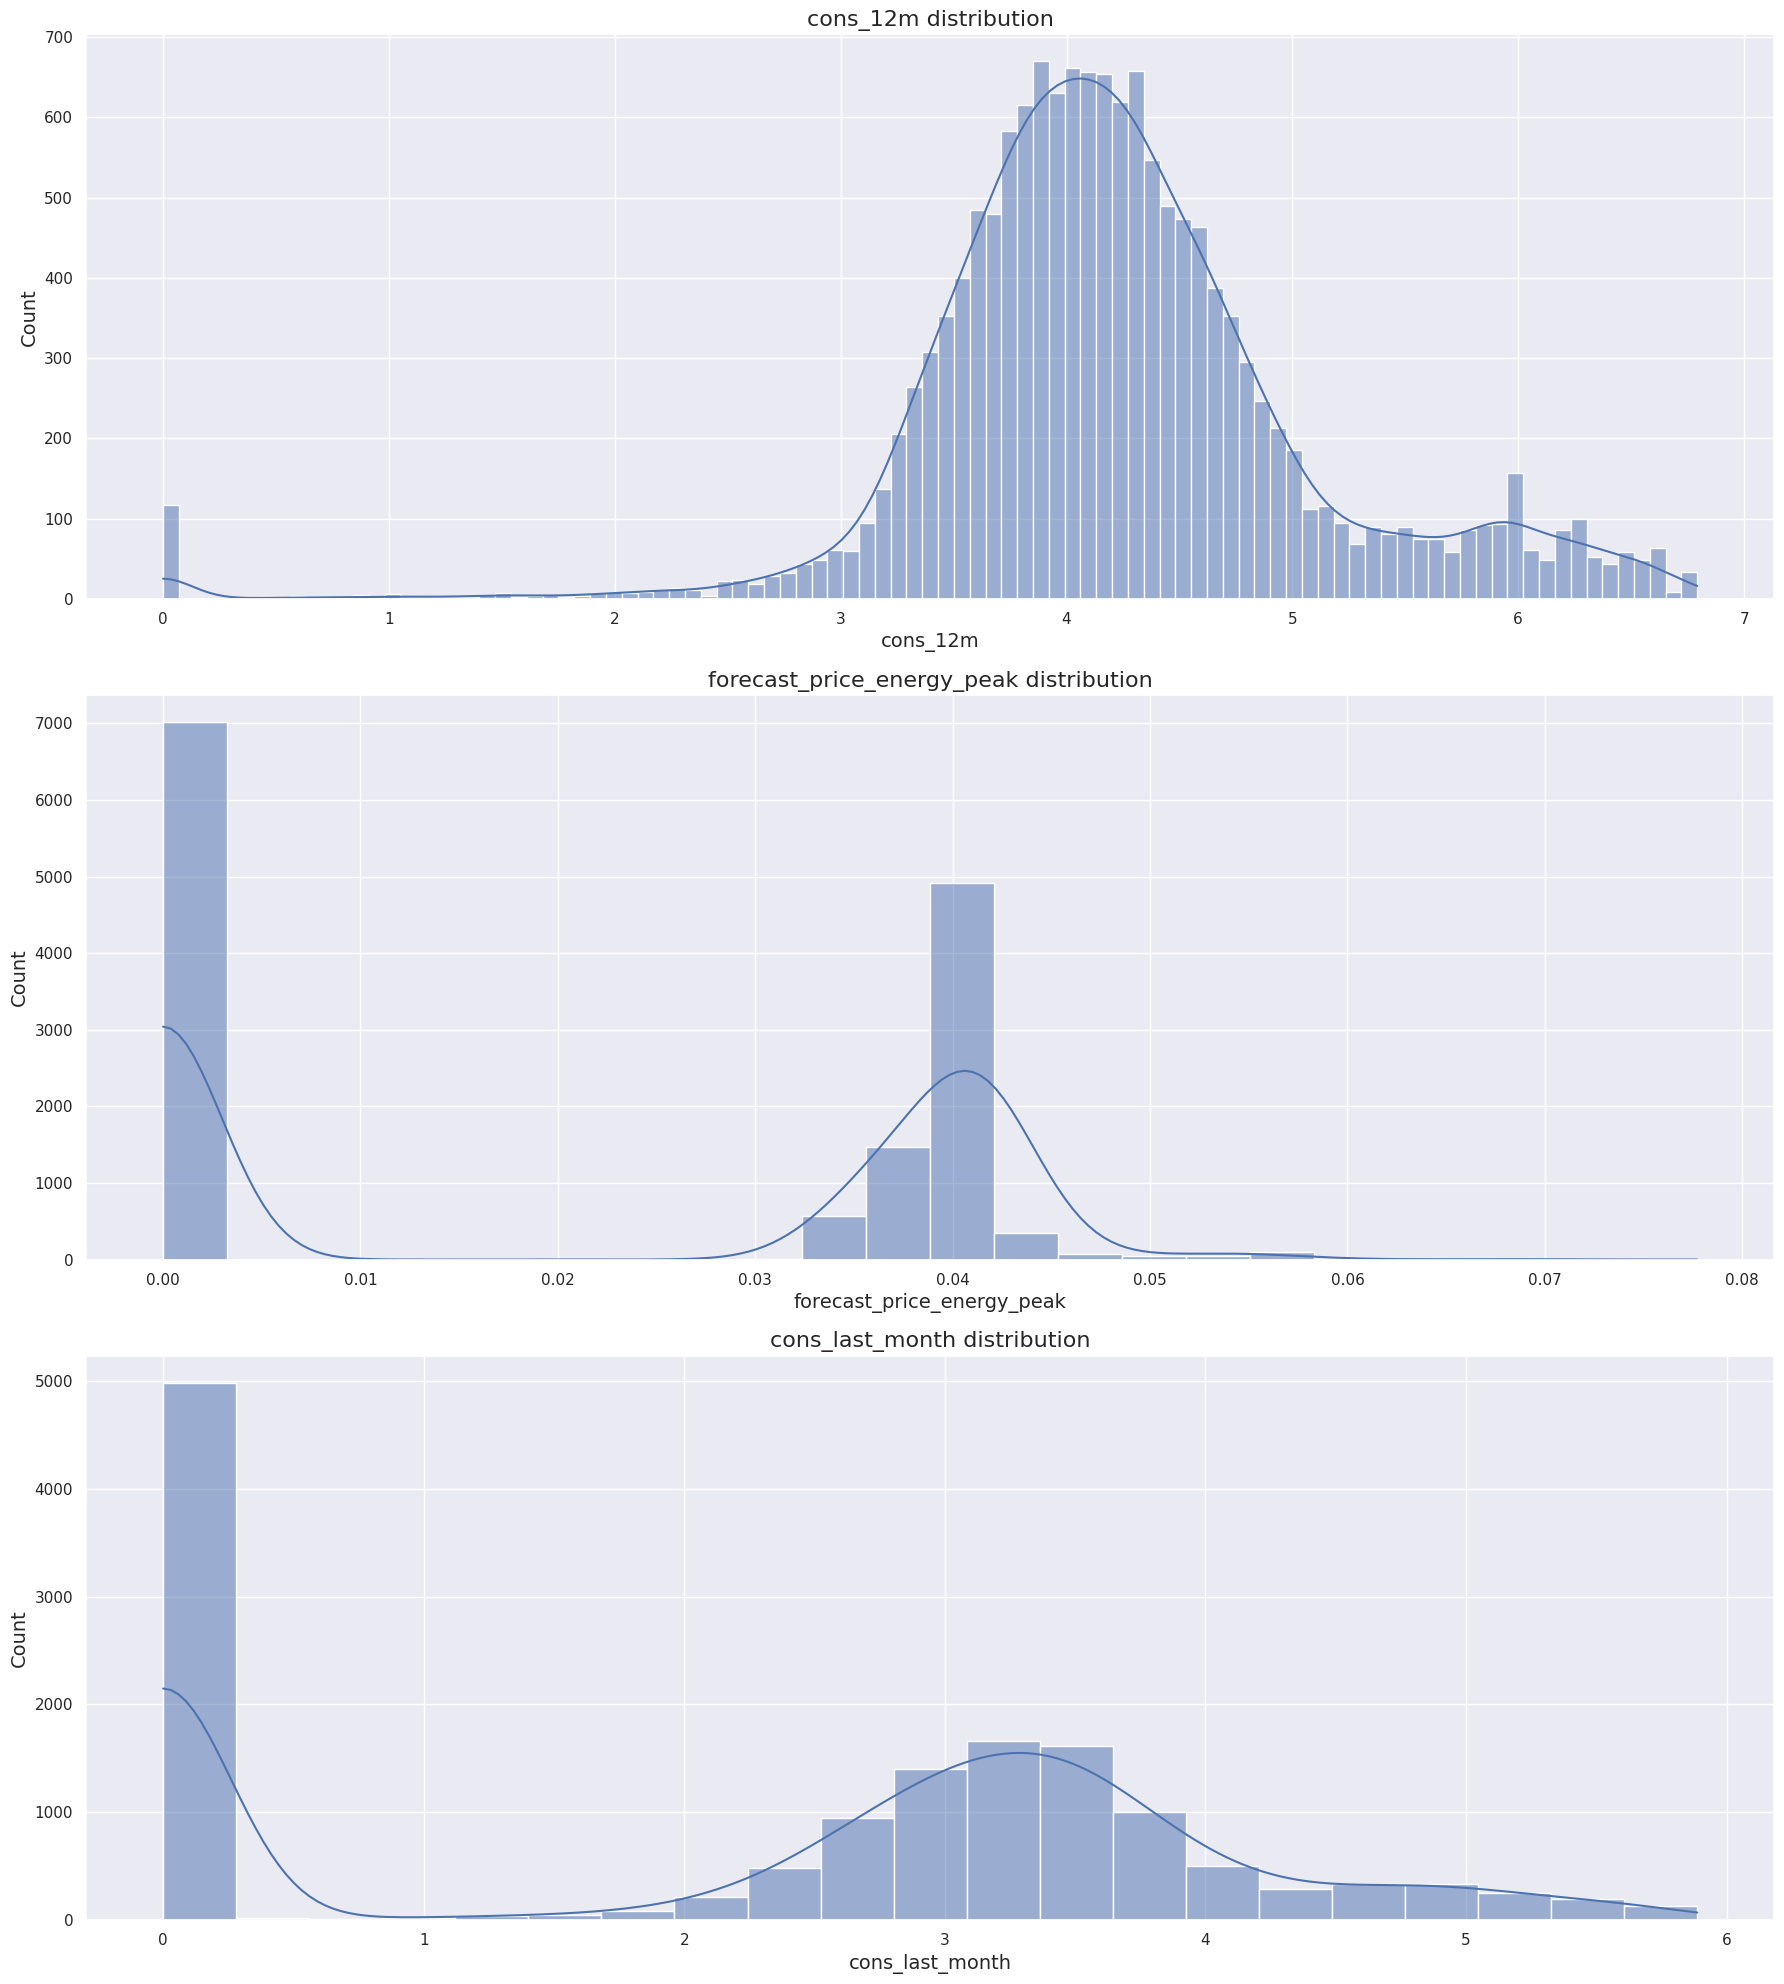

In [ ]:
cols = ["cons_12m", "forecast_price_energy_peak", "cons_last_month"]

# Set up subplots
fig, axs = plt.subplots(nrows=len(cols), figsize=(18, 20))

# Loop through each column and plot
for ax, col in zip(axs, cols):
    sns.histplot(client_df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"{col} distribution", fontsize=16)
    ax.set_xlabel(col, fontsize=14)
    ax.set_ylabel("Count", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
client_df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,...,months_to_end,months_modif_prod,months_renewal,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,...,6,2,6,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.000000,0.0,1.237292,0.059075,0.000000,...,8,76,4,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.000000,0.0,1.599009,0.066622,0.036589,...,4,68,8,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.000000,0.0,1.318689,0.059448,0.000000,...,3,69,9,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,2.721811,0.0,2.122969,0.048014,0.041399,...,3,71,9,0,0,0,0,1,0,0


### Correlations

Creating new featuers requires trial and error and requires iteration. To determine if we are on the right track, we can check the correlation between our new features with our target variable of interest. We also want to check if features are highly correlated with each other (and leave only one in the model), since predictive models work best when the features are uncorrelated.

In [ ]:
correlation = client_df.drop(columns=['id']).corr()

In [ ]:
# Plot correlation
plt.figure(figsize=(45, 45))
sns.heatmap(
    correlation,
    xticklabels=correlation.columns.values,
    yticklabels=correlation.columns.values,
    annot=True,
    annot_kws={'size': 12}
)
# Axis ticks size
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.show()

Output hidden; open in https://colab.research.google.com to view.


We will remove two variables that exhibit a high correlation with other independent features.

In [ ]:
client_df = client_df.drop(columns=['num_years_antig', 'forecast_cons_year'])
client_df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_to_end,months_modif_prod,months_renewal,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,1.619163,...,6,2,6,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.059075,0.000000,1.656207,...,8,76,4,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.066622,0.036589,1.656207,...,4,68,8,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.059448,0.000000,1.656207,...,3,69,9,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.048014,0.041399,1.619163,...,3,71,9,0,0,0,0,1,0,0


## Verify Final Columns in `client_df`

Let's explicitly check if the `client_df` now contains *only* the columns you specified.

In [ ]:
client_df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_to_end,months_modif_prod,months_renewal,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,1.619163,...,6,2,6,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.059075,0.000000,1.656207,...,8,76,4,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.066622,0.036589,1.656207,...,4,68,8,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.059448,0.000000,1.656207,...,3,69,9,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.048014,0.041399,1.619163,...,3,71,9,0,0,0,0,1,0,0


---

## 3. Modelling

We now have a dataset containing features that we have engineered and we are ready to start training a predictive model. Remember, we only need to focus on training a `Random Forest` classifier.

In [ ]:
df = client_df.copy()
df.head()

,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,months_to_end,months_modif_prod,months_renewal,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw
0,24011ae4ebbe3035111d65fa7c15bc57,0.000000,4.739944,0.000000,0.000000,0.0,0.444045,0.047073,0.040659,1.619163,...,6,2,6,0,1,0,0,0,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,3.668479,0.000000,0.000000,2.280920,0.0,1.237292,0.059075,0.000000,1.656207,...,8,76,4,0,0,0,0,1,0,0
2,764c75f661154dac3a6c254cd082ea7d,2.736397,0.000000,0.000000,1.689841,0.0,1.599009,0.066622,0.036589,1.656207,...,4,68,8,0,1,0,0,1,0,0
3,bba03439a292a1e166f80264c16191cb,3.200029,0.000000,0.000000,2.382089,0.0,1.318689,0.059448,0.000000,1.656207,...,3,69,9,0,0,1,0,1,0,0
4,149d57cf92fc41cf94415803a877cb4b,3.646011,0.000000,2.721811,2.650065,0.0,2.122969,0.048014,0.041399,1.619163,...,3,71,9,0,0,0,0,1,0,0


In [ ]:
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

### Data sampling

The first thing we want to do is split our dataset into training and test samples. The reason why we do this, is so that we can simulate a real life situation by generating predictions for our test sample, without showing the predictive model these data points. This gives us the ability to see how well our model is able to generalise to new data, which is critical.

A typical % to dedicate to testing is between 20-30, for this example we will use a 75-25% split between train and test respectively.

In [ ]:
# Make a copy of our data
train_df = df.copy()

# Separate target variable from independent variables
y = df['churn']
X = df.drop(columns=['id', 'churn'])
print(X.shape)
print(y.shape)

(14606, 59)
(14606,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(10954, 59)
(10954,)
(3652, 59)
(3652,)


### Model training

Once again, we are using a `Random Forest` classifier in this example. A Random Forest sits within the category of `ensemble` algorithms because internally the `Forest` refers to a collection of `Decision Trees` which are tree-based learning algorithms. As the data scientist, you can control how large the forest is (that is, how many decision trees you want to include).

The reason why an `ensemble` algorithm is powerful is because of the laws of averaging, weak learners and the central limit theorem. If we take a single decision tree and give it a sample of data and some parameters, it will learn patterns from the data. It may be overfit or it may be underfit, but that is now our only hope, that single algorithm.

With `ensemble` methods, instead of banking on 1 single trained model, we can train 1000's of decision trees, all using different splits of the data and learning different patterns. It would be like asking 1000 people to all learn how to code. You would end up with 1000 people with different answers, methods and styles! The weak learner notion applies here too, it has been found that if you train your learners not to overfit, but to learn weak patterns within the data and you have a lot of these weak learners, together they come together to form a highly predictive pool of knowledge! This is a real life application of many brains are better than 1.

Now instead of relying on 1 single decision tree for prediction, the random forest puts it to the overall views of the entire collection of decision trees. Some ensemble algorithms using a voting approach to decide which prediction is best, others using averaging.

As we increase the number of learners, the idea is that the random forest's performance should converge to its best possible solution.

Some additional advantages of the random forest classifier include:

- The random forest uses a rule-based approach instead of a distance calculation and so features do not need to be scaled
- It is able to handle non-linear parameters better than linear based models

On the flip side, some disadvantages of the random forest classifier include:

- The computational power needed to train a random forest on a large dataset is high, since we need to build a whole ensemble of estimators.
- Training time can be longer due to the increased complexity and size of thee ensemble

In [ ]:
model = RandomForestClassifier(
    n_estimators=1000)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=1000)

### Evaluation

Now let's evaluate how well this trained model is able to predict the values of the test dataset.

I'm going to use 3 metrics to evaluate performance:

- Accuracy = the ratio of correctly predicted observations to the total observations
- Precision = the ability of the classifier to not label a negative sample as positive
- Recall = the ability of the classifier to find all the positive samples

The reason why I'm using these three metrics is because a simple accuracy is not always a good measure to use.



In [ ]:
predictions = model.predict(X_test)
tn, fp, fn, tp = metrics.confusion_matrix(y_test, predictions).ravel()

In [ ]:
y_test.value_counts()

,count
churn,
0,3286
1,366


In [ ]:
print(f"True positives: {tp}")
print(f"False positives: {fp}")
print(f"True negatives: {tn}")
print(f"False negatives: {fn}\n")

print(f"Accuracy: {metrics.accuracy_score(y_test, predictions)}")
print(f"Precision: {metrics.precision_score(y_test, predictions)}")
print(f"Recall: {metrics.recall_score(y_test, predictions)}")

True positives: 21
False positives: 2
True negatives: 3284
False negatives: 345

Accuracy: 0.9049835706462213
Precision: 0.9130434782608695
Recall: 0.05737704918032787


Looking at these results there are a few things to point out:

- Within the test set about 10% of the rows are churners (churn = 1).
- Looking at the true negatives, we have 3282 out of 3286. This means that out of all the negative cases (churn = 0), we predicted 3282 as negative (hence the name True negative). This is great!
- Looking at the false negatives, this is where we have predicted a client to not churn (churn = 0) when in fact they did churn (churn = 1). This number is quite high at 348, we want to get the false negatives to as close to 0 as we can, so this would need to be addressed when improving the model.
- Looking at false positives, this is where we have predicted a client to churn when they actually didnt churn. For this value we can see there are 4 cases, which is great!
- With the true positives, we can see that in total we have 366 clients that churned in the test dataset. However, we are only able to correctly identify 18 of those 366, which is very poor.
- Looking at the accuracy score, this is very misleading! Hence the use of precision and recall is important. The accuracy score is high, but it does not tell us the whole story.
- Looking at the precision score, this shows us a score of 0.82 which is not bad, but could be improved.
- However, the recall shows us that the classifier has a very poor ability to identify positive samples. This would be the main concern for improving this model!

So overall, we're able to very accurately identify clients that do not churn, but we are not able to predict cases where clients do churn! What we are seeing is that a high % of clients are being identified as not churning when they should be identified as churning. This in turn tells me that the current set of features are not discriminative enough to clearly distinguish between churners and non-churners.

A data scientist at this point would go back to feature engineering to try and create more predictive features. They may also experiment with optimising the parameters within the model to improve performance. For now, lets dive into understanding the model a little more.

### Model understanding

A simple way of understanding the results of a model is to look at feature importances. Feature importances indicate the importance of a feature within the predictive model, there are several ways to calculate feature importance, but with the Random Forest classifier, we're able to extract feature importances using the built-in method on the trained model. In the Random Forest case, the feature importance represents the number of times each feature is used for splitting across all trees.

In [ ]:
feature_importances = pd.DataFrame({
    'features': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=True).reset_index()


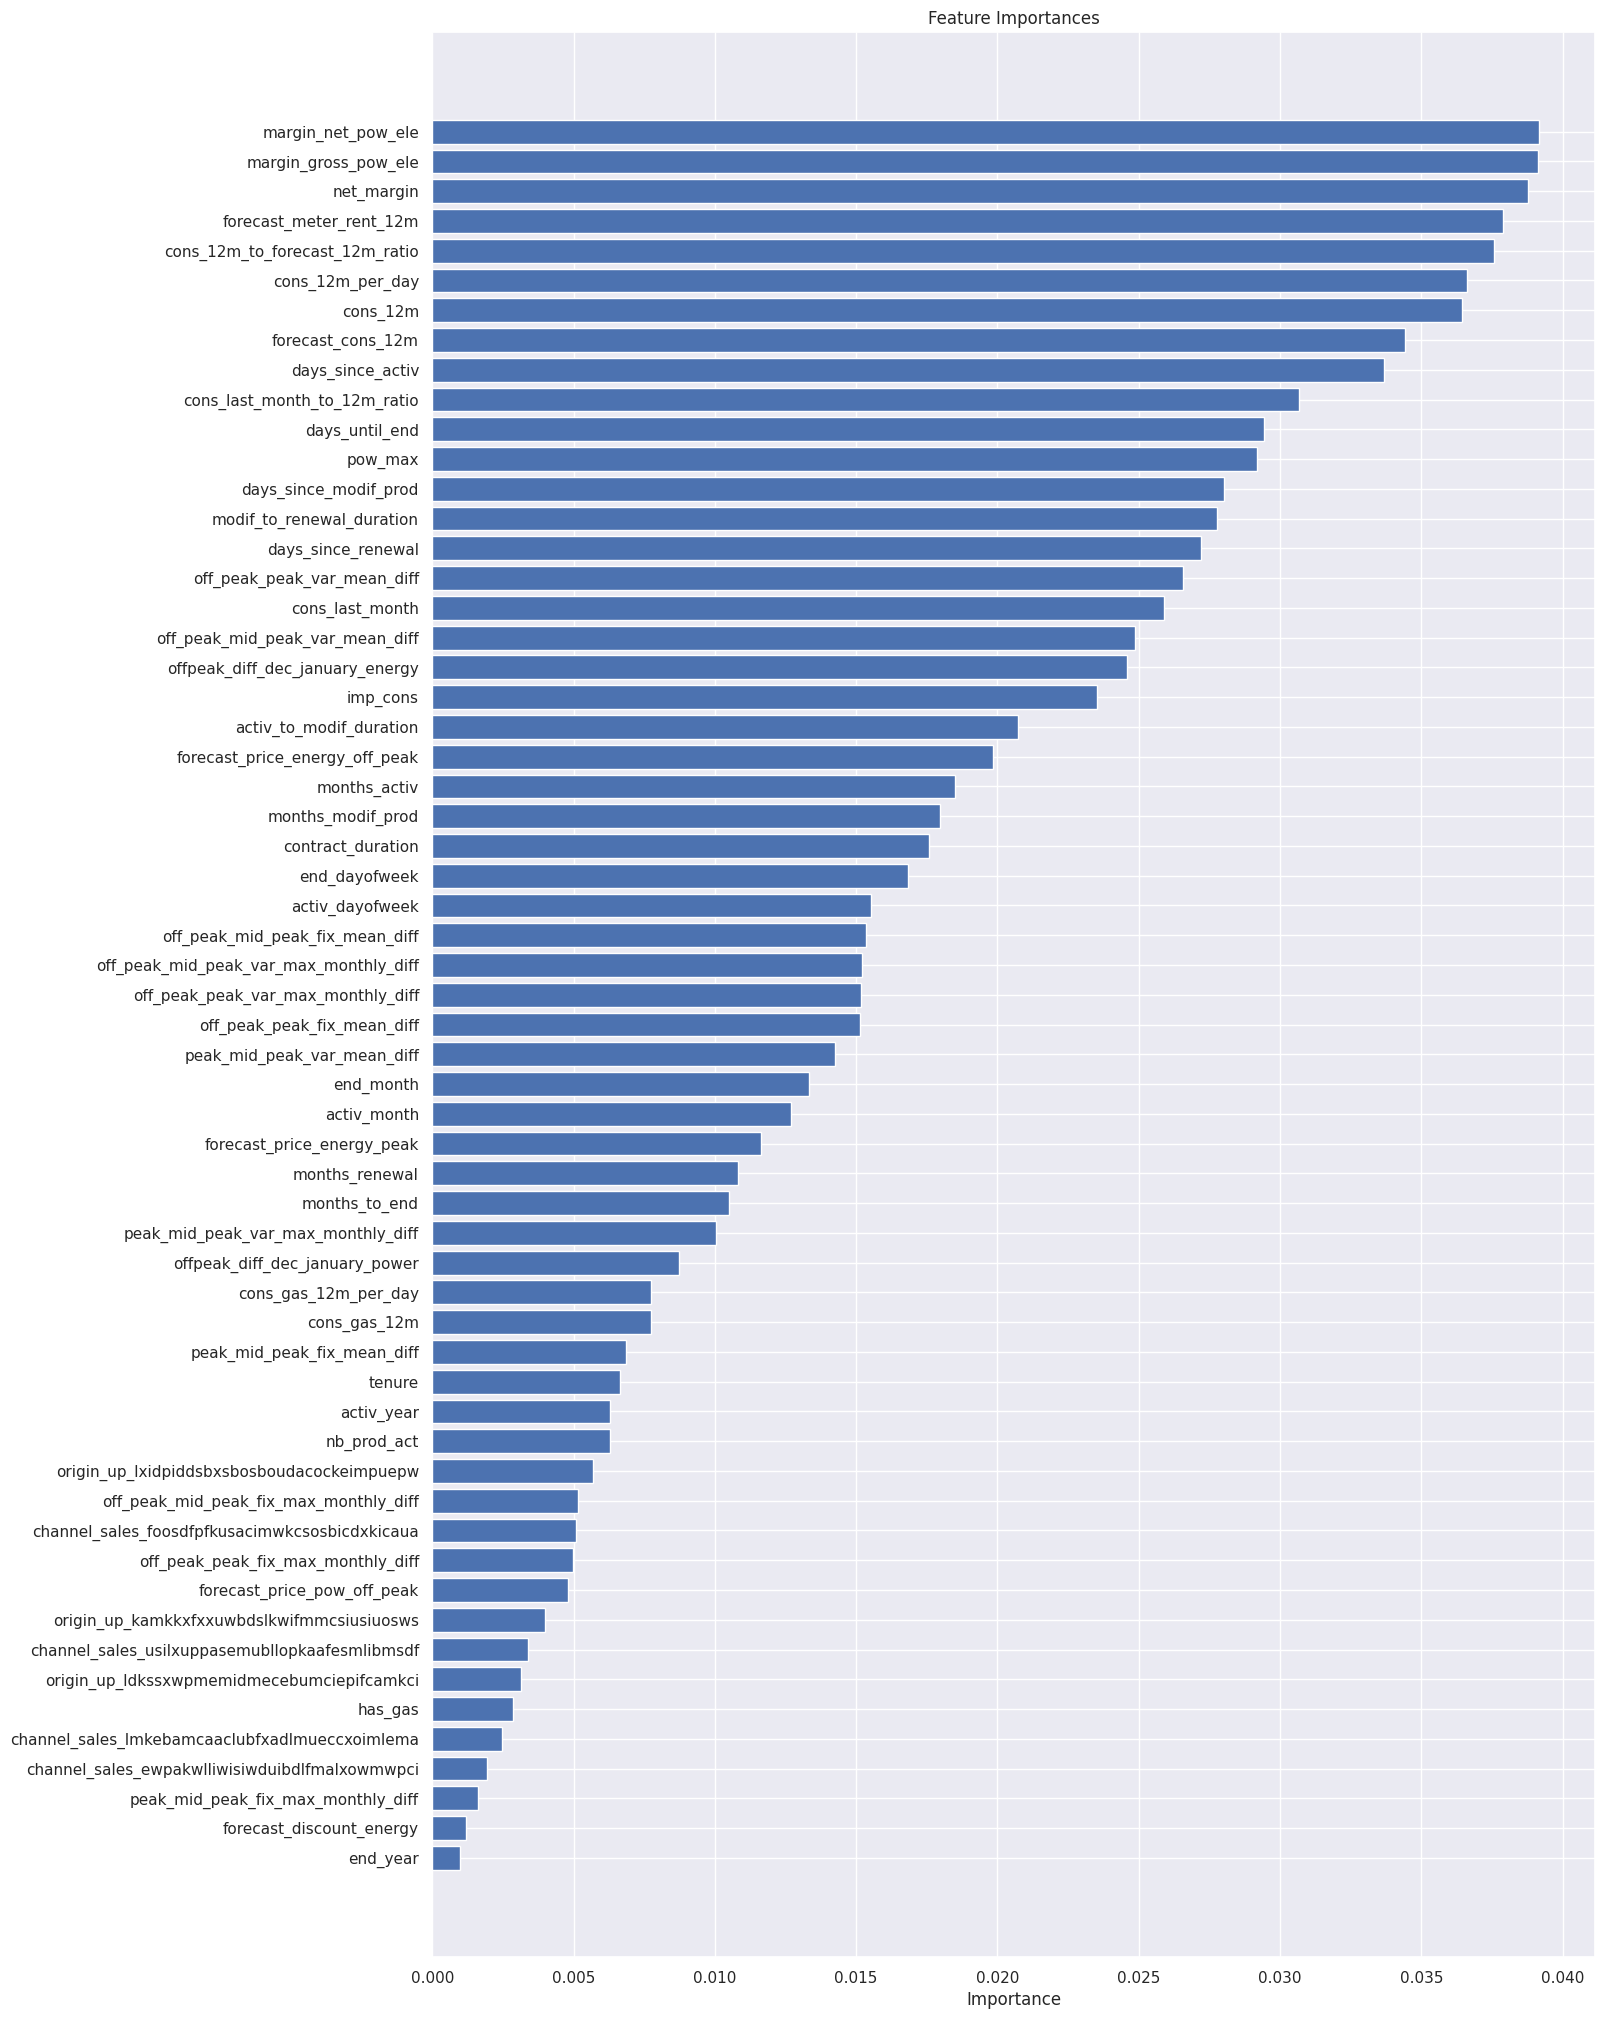

In [ ]:
plt.figure(figsize=(15, 25))
plt.title('Feature Importances')
plt.barh(range(len(feature_importances)), feature_importances['importance'], color='b', align='center')
plt.yticks(range(len(feature_importances)), feature_importances['features'])
plt.xlabel('Importance')
plt.show()

From this chart, we can observe the following points:

- Net margin and consumption over 12 months is a top driver for churn in this model
- Margin on power subscription also is an influential driver
- Time seems to be an influential factor, especially the number of months they have been active, their tenure and the number of months since they updated their contract
- The feature that our colleague recommended is in the top half in terms of how influential it is and some of the features built off the back of this actually outperform it
- Our price sensitivity features are scattered around but are not the main driver for a customer churning

The last observation is important because this relates back to our original hypothesis:

    > Is churn driven by the customers' price sensitivity?

Based on the output of the feature importances, it is not a main driver but it is a weak contributor. However, to arrive at a conclusive result, more experimentation is needed.

# **Summary**

Here's a summary of the key insights from this project:

- 1. Data Overview and Quality:

Two datasets, client_df (client information) and price_df (pricing information), were loaded.
Initial inspection revealed no immediate missing values (as indicated by info()), but further analysis showed 'MISSING' string values in channel_sales (25.50%) and origin_up (0.44%), which were converted to np.nan.
No duplicate rows were found in either dataset, indicating good data integrity.
- 2. Churn Distribution (Target Variable):

A significant class imbalance was observed, with approximately 9.7% of clients churning and 90.3% being retained. This is a crucial factor for model training.
- 3. Feature Distributions:

Numerical Features (client_df): Many numerical features, especially consumption-related ones (cons_12m, cons_gas_12m, cons_last_month), were highly positively skewed. This necessitated log transformations during feature engineering to normalize their distributions.
Price Features (price_df): Variable and fixed price components for off-peak, peak, and mid-peak periods showed that price_off_peak_var and price_off_peak_fix had more concentrated distributions, while peak and mid-peak prices were often zero or very low for many customers.
- 4. Categorical Feature Insights:

channel_sales: 'foosdfpfkusacimwkcsosbicdxkicaua' was the dominant sales channel. The 'MISSING' values in this column were noted as potentially important.
has_gas: Clients with gas contracts (t) showed a slightly lower churn rate (8.18%) compared to those without gas contracts (f) (10.05%), suggesting it might be a predictive feature.
origin_up: This feature had several categories, with lxidpiddsbxsbosboudacockeimpuepw having the highest churn rate (12.58%) among the major categories.
- 5. Feature Engineering:

Date-based features: Original date columns were converted to datetime objects, and new features were created to capture time-based insights, such as modif_to_renewal_duration, days_since_activ, months_activ, and tenure. Notably, clients with shorter tenure (e.g., 2-4 years) showed higher churn rates.
Consumption-based features: Ratios and per-day consumption metrics were engineered, such as cons_last_month_to_12m_ratio and cons_12m_per_day.
Price-related features: New features were derived to capture average and maximum price changes across different periods (e.g., offpeak_diff_dec_january_energy, off_peak_peak_var_mean_diff, off_peak_peak_var_max_monthly_diff). These aim to capture price sensitivity.
Categorical Encoding: channel_sales and origin_up were one-hot encoded, with rare categories (less than 100 occurrences) removed.
Numerical Transformation: Highly skewed numerical features were log-transformed to improve their distribution.
- 6. Correlation Analysis:

A correlation heatmap revealed generally low linear correlations between most features and the churn target variable. This suggested that churn might be driven by non-linear relationships or combinations of features, and feature engineering was crucial.
Highly correlated independent features (num_years_antig and forecast_cons_year) were dropped to reduce multicollinearity.
- 7. Modeling (Random Forest Classifier):

Initial Model Performance: The initial Random Forest model, trained without hyperparameter tuning, showed high accuracy (0.90) but very poor recall (0.057). This confirmed the challenge posed by the class imbalance; the model was good at predicting non-churners but struggled to identify actual churners.
Feature Importances (Initial Model): Key drivers for churn were identified as net_margin, cons_12m, margin_gross_pow_ele, and various time-based features (months_activ, tenure, months_modif_prod). Price sensitivity features were scattered and not the main drivers, challenging the initial hypothesis that price sensitivity is a primary churn driver.
